<a href="https://colab.research.google.com/github/dedoubleyou1/GaussianFractalLOD/blob/main/gaussian_lod_2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Consolidated Experiment: Distributed Mass Guidance & Moment-Matched 9-Grid

This section contains all the key functionality extracted and preserved for the current frontier of the experiment.

In [ ]:
# Pure Batched Tensor Architecture
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Tensor Refinement Module (Fully Fourier Compressed) ---
class TensorRefinement(nn.Module):
    def __init__(self, num_parents, fourier_degree=4, device='cpu'):
        super().__init__()
        self.num_parents = num_parents # Kept for API compatibility
        self.num_children = 9
        self.device = device
        self.fourier_degree = fourier_degree

        offset = math.sqrt(2.0 / 3.0)
        base_delta = torch.tensor([
            [-offset, -offset], [ 0.0, -offset], [ offset, -offset],
            [-offset,  0.0],    [ 0.0,  0.0],    [ offset,  0.0],
            [-offset,  offset], [ 0.0,  offset], [ offset,  offset]
        ], device=device)
        self.register_buffer('base_Delta', base_delta)

        num_features = 2 * fourier_degree + 1

        # Learnable Fourier coefficients for ALL parameters!
        # Shape: (Features, Children, Dims)
        self.fourier_mu = nn.Parameter(torch.zeros(num_features, self.num_children, 2, device=device))
        self.fourier_sigma = nn.Parameter(torch.zeros(num_features, self.num_children, 1, device=device))
        self.fourier_a = nn.Parameter(torch.zeros(num_features, self.num_children, 1, device=device))
        self.fourier_q = nn.Parameter(torch.zeros(num_features, self.num_children, 1, device=device))

        # Initialize the DC terms (constant base values)
        with torch.no_grad():
            self.fourier_sigma[0, :, 0] = math.log(1.0 / 3.0)
            self.fourier_a[0, :, 0] = 3.0
            self.fourier_q[0, :, 0] = 0.0

    def forward(self, mu, sigma, color, opacity):
        N = mu.shape[0]

        # 1. Compute Radial Fourier Features for the parents
        theta = torch.atan2(mu[:, 1], mu[:, 0]) # Shape: (N,)

        features = [torch.ones_like(theta)] # DC term (constant)
        for k in range(1, self.fourier_degree + 1):
            features.append(torch.cos(k * theta))
            features.append(torch.sin(k * theta))

        F_basis = torch.stack(features, dim=1) # Shape: (N, 2K + 1)

        # 2. Predict ALL residuals and parameters via Fourier projections
        res_mu = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_mu)         # (N, 9, 2)
        delta_sigma = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_sigma) # (N, 9, 1)
        a = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_a)               # (N, 9, 1)
        q = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_q)               # (N, 9, 1)

        # Expand parent parameters: (N, D) -> (N, 1, D)
        mu_expanded = mu.unsqueeze(1)
        sigma_expanded = sigma.unsqueeze(1)
        color_expanded = color.unsqueeze(1)
        opacity_expanded = opacity.unsqueeze(1)

        # Compute child parameters in a single batch operation
        mu_child = mu_expanded + sigma_expanded * (self.base_Delta + res_mu)
        sigma_child = sigma_expanded * torch.exp(delta_sigma)
        color_child = color_expanded.expand(-1, self.num_children, -1)
        opacity_child = opacity_expanded * torch.sigmoid(a)
        split_prob_child = torch.sigmoid(q)

        # Flatten out the children: (N, 9, D) -> (N*9, D)
        N_new = N * self.num_children
        return (
            mu_child.reshape(N_new, 2),
            sigma_child.reshape(N_new, 1),
            color_child.reshape(N_new, 1),
            opacity_child.reshape(N_new, 1),
            split_prob_child.reshape(N_new, 1)
        )

# --- Unified Tensor Model ---
class TensorGaussianLOD(nn.Module):
    def __init__(self, num_levels=3, fourier_degree=4, device='cpu'):
        super().__init__()
        self.num_levels = num_levels
        self.device = device

        # Root parameters (N=1)
        self.root_mu = nn.Parameter(torch.zeros(1, 2, device=device))
        self.root_sigma = nn.Parameter(torch.ones(1, 1, device=device) * 0.5)
        self.root_color = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_opacity = nn.Parameter(torch.ones(1, 1, device=device))
        self.root_split_logit = nn.Parameter(torch.zeros(1, 1, device=device))

        # Cascading Refinement Modules
        self.refinements = nn.ModuleList()
        num_parents = 1
        for _ in range(num_levels):
            self.refinements.append(TensorRefinement(num_parents, fourier_degree=fourier_degree, device=device))
            num_parents *= 9

    def get_lod_tensors(self):
        """Forward pass: Generates the parameters for every LOD layer."""
        lods = []

        # LOD 0 (Root)
        split_prob = torch.sigmoid(self.root_split_logit)
        lods.append({
            'mu': self.root_mu, 'sigma': self.root_sigma, 'color': self.root_color,
            'opacity': self.root_opacity, 'split_prob': split_prob
        })

        # LOD 1 to N
        for l in range(self.num_levels):
            parent = lods[-1]
            ref = self.refinements[l]
            mu_c, sigma_c, color_c, opacity_c, split_prob_c = ref(
                parent['mu'], parent['sigma'], parent['color'], parent['opacity']
            )
            lods.append({
                'mu': mu_c, 'sigma': sigma_c, 'color': color_c,
                'opacity': opacity_c, 'split_prob': split_prob_c
            })

        return lods

# --- Pure Tensor Renderer ---
class TensorRendererAnalytics:
    def __init__(self, image_size, device='cpu'):
        self.image_size = image_size
        self.device = device
        H, W = image_size
        y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
        self.grid_flat = torch.stack([x, y], dim=-1).view(-1, 2) # (H*W, 2)

    def get_frontier_tensors(self, lods, target_lod):
        frontiers = []
        current_prob = torch.ones(1, 1, device=self.device)

        for l in range(target_lod + 1):
            level_data = lods[l]
            split_prob = level_data['split_prob']

            if l == target_lod:
                prob_stop = current_prob
            else:
                prob_stop = current_prob * (1 - split_prob)

            frontiers.append({
                'mu': level_data['mu'], 'sigma': level_data['sigma'],
                'color': level_data['color'], 'opacity': level_data['opacity'],
                'prob': prob_stop
            })

            if l < target_lod:
                current_prob = current_prob * split_prob
                current_prob = current_prob.unsqueeze(1).expand(-1, 9, -1).reshape(-1, 1)

        mu = torch.cat([f['mu'] for f in frontiers], dim=0)
        sigma = torch.cat([f['sigma'] for f in frontiers], dim=0)
        color = torch.cat([f['color'] for f in frontiers], dim=0)
        opacity = torch.cat([f['opacity'] for f in frontiers], dim=0)
        prob = torch.cat([f['prob'] for f in frontiers], dim=0)

        return mu, sigma, color, opacity, prob

    def render(self, lods, target_lod):
        mu, sigma, color, opacity, prob = self.get_frontier_tensors(lods, target_lod)
        H, W = self.image_size

        diff = self.grid_flat.unsqueeze(0) - mu.unsqueeze(1)
        dist_sq = torch.sum(diff ** 2, dim=-1)
        gaussian = torch.exp(-dist_sq / (2 * sigma**2 + 1e-8))

        alpha = (opacity * prob) * gaussian

        beta = 1.0 - alpha
        beta_flipped = torch.flip(beta, dims=[0])
        cum_beta_flipped = torch.cumprod(beta_flipped, dim=0)

        T_flipped = torch.cat([torch.ones(1, H * W, dtype=torch.float32, device=self.device), cum_beta_flipped[:-1]], dim=0)
        T = torch.flip(T_flipped, dims=[0])

        bg_contrib = cum_beta_flipped[-1]
        fg_contrib = torch.sum(color * alpha * T, dim=0)

        canvas = bg_contrib + fg_contrib
        sum_alpha = torch.sum(alpha, dim=0)

        return torch.clamp(canvas.view(H, W), 0, 1), sum_alpha.view(H, W)

In [ ]:
# Re-running loss modules
# --- Loss Modules ---
def get_gaussian_kernel(kernel_size=15, sigma=3.0):
    """Creates a 2D Gaussian kernel to distribute the mass field."""
    x_coord = torch.arange(kernel_size)
    x_grid = x_coord.repeat(kernel_size).view(kernel_size, kernel_size)
    y_grid = x_grid.t()
    xy_grid = torch.stack([x_grid, y_grid], dim=-1).float()

    mean = (kernel_size - 1) / 2.
    variance = sigma**2.

    gaussian_kernel = (1. / (2. * math.pi * variance)) * torch.exp(
        -torch.sum((xy_grid - mean)**2., dim=-1) / (2 * variance)
    )
    gaussian_kernel = gaussian_kernel / torch.sum(gaussian_kernel)
    return gaussian_kernel.view(1, 1, kernel_size, kernel_size)

class DistributedMassLossModule(nn.Module):
    def __init__(self, lambda_l1=0.1, lambda_guided=0.5):
        super().__init__()
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()
        self.lambda_l1 = lambda_l1
        self.lambda_guided = lambda_guided
        self.kernel = get_gaussian_kernel(kernel_size=15, sigma=3.0)

    def compute_loss(self, canvas, mass_field, target_img):
        # 1. Base Image Loss: Optimize the final composited canvas against the target image
        # This forces the Gaussians to achieve true solid opacity (0.0 for object, 1.0 for background)
        base_mse = self.mse(canvas, target_img)
        base_l1 = self.l1(canvas, target_img)

        # 2. Distributed/Guided loss: Use the blurred mass field to widen the gradient basin
        target_mass = 1.0 - target_img
        P = mass_field.unsqueeze(0).unsqueeze(0)
        T = target_mass.unsqueeze(0).unsqueeze(0)

        kernel = self.kernel.to(P.device)
        P_blur = F.conv2d(P, kernel, padding=kernel.size(-1)//2)
        T_blur = F.conv2d(T, kernel, padding=kernel.size(-1)//2)

        guided_loss = self.mse(P_blur, T_blur)

        return base_mse + self.lambda_l1 * base_l1 + self.lambda_guided * guided_loss

    def compute_total_loss(self, root, renderer, target_img, max_lod):
        total_loss = 0.0
        for lod in range(max_lod + 1):
            canvas, mass_field = renderer.render(root, lod)
            loss = self.compute_loss(canvas, mass_field, target_img)
            total_loss += loss
        return total_loss

In [ ]:
# Re-running training setup
# --- Training Setup ---
def train_shape_tensor(target_img, H, W, name="Shape", iterations=200, device='cpu'):
    print(f"Training {name} on {device} using Fully Fourier Compressed Architecture...")
    target_img = target_img.to(device)

    model = TensorGaussianLOD(num_levels=3, fourier_degree=4, device=device).to(device)
    renderer = TensorRendererAnalytics(image_size=(H, W), device=device)
    loss_module = DistributedMassLossModule(lambda_l1=0.1, lambda_guided=0.5).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.03)

    max_lod = 3
    for i in range(iterations):
        optimizer.zero_grad()

        # Single forward pass to generate all parameter blocks
        lods = model.get_lod_tensors()

        total_loss = 0.0
        for lod in range(max_lod + 1):
            canvas, mass_field = renderer.render(lods, lod)
            loss = loss_module.compute_loss(canvas, mass_field, target_img)
            total_loss += loss

        total_loss.backward()
        optimizer.step()

        if (i + 1) % 50 == 0:
            print(f"  Iteration {i+1}/{iterations}, Loss: {total_loss.item():.4f}")

    return model, renderer

In [ ]:
# Re-running execution
# --- Execution and Visualization ---
import torchvision.transforms as T
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using backend: {device}")

H, W = 64, 64
y, x = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing='ij')

# Create Target: Black Circle on White Background
dist_sq_target = x**2 + y**2
target_circle = (dist_sq_target >= 0.25).float()

# Create Target: Black Square on White Background
target_square_mask = (torch.abs(x) < 0.5) & (torch.abs(y) < 0.5)
target_square = (~target_square_mask).float()

# Image Loading Pipeline
def load_target_image(path, H, W):
    img = Image.open(path).convert("RGBA")
    # Composite over white background to handle transparency
    bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
    composite = Image.alpha_composite(bg, img)
    gray = composite.convert("L")
    # Resize and convert to tensor [0, 1]
    tensor = T.ToTensor()(T.Resize((H, W))(gray)).squeeze(0)
    return tensor

# Dictionary of all targets
targets = {
    "Circle": target_circle,
    "Square": target_square,
    "Leaf": load_target_image('/content/sample_data/leaf.png', H, W),
    "Puzzle": load_target_image('/content/sample_data/puzzle.png', H, W),
    "Head": load_target_image('/content/sample_data/head.png', H, W)
}

# Helper to cleanly get the image off GPU for plotting
def get_img_tensor(renderer, model, lod):
    lods = model.get_lod_tensors()
    return renderer.render(lods, lod)[0].cpu().detach().numpy()

# Visualize
fig, axes = plt.subplots(len(targets), 5, figsize=(20, 4 * len(targets)))

for i, (name, target) in enumerate(targets.items()):
    # Train using the pure tensor functions
    model, renderer = train_shape_tensor(target, H, W, name, iterations=200, device=device)

    # Plot Target
    axes[i, 0].imshow(target.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f"Target {name}")

    # Plot LOD 0 to 3
    for lod in range(4):
        img = get_img_tensor(renderer, model, lod)
        axes[i, lod+1].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[i, lod+1].set_title(f"LOD {lod} (Render)")

plt.tight_layout()
plt.show()

Using backend: cuda


FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/leaf.png'

## Parameter Compression Analysis

This section mathematically compares the memory footprint (parameter count) of the **Independent Per-Node** baseline versus the **Fully Fourier Compressed** architecture as the Level of Detail (LOD) depth increases.

LOD   | Children   | Indep. Params   | Fourier Params  | Layer Compression    | Total Compression
------------------------------------------------------------------------------------------
1     | 9          | 45              | 405             | 0.11x                | 0.11x
2     | 81         | 405             | 405             | 1.00x                | 0.56x
3     | 729        | 3645            | 405             | 9.00x                | 3.37x
4     | 6561       | 32805           | 405             | 81.00x                | 22.78x
5     | 59049      | 295245          | 405             | 729.00x                | 164.02x
6     | 531441     | 2657205         | 405             | 6561.00x                | 1230.19x


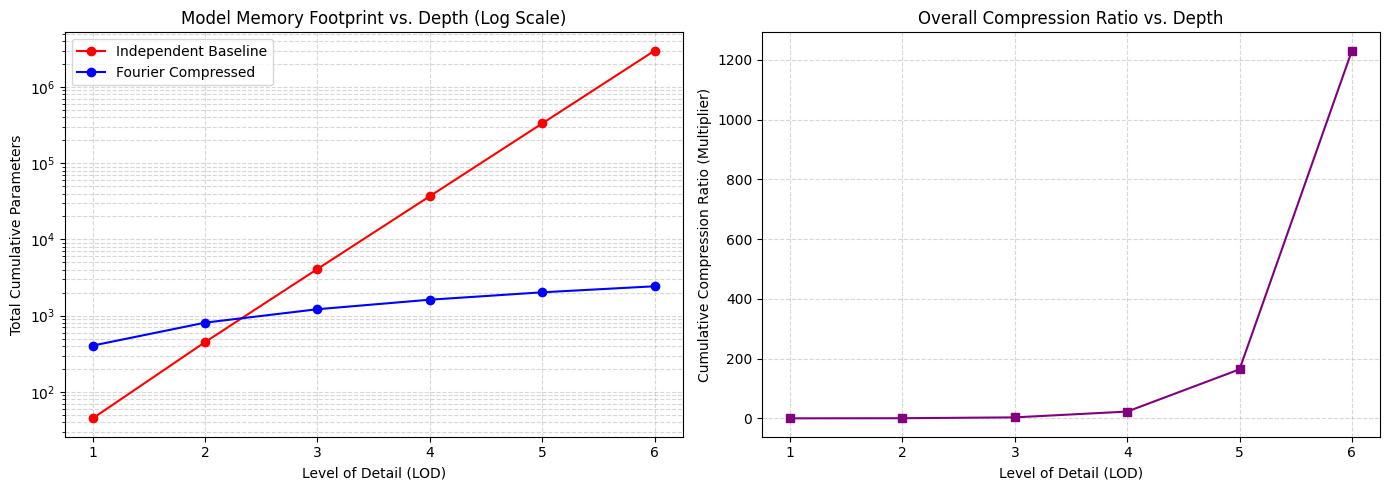

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Hyperparameters ---
num_children_per_split = 9
params_per_child = 5  # (res_mu_x, res_mu_y, delta_sigma, a, q)
fourier_degree = 4
fourier_features = 2 * fourier_degree + 1  # DC term + sine/cosine pairs

max_lod_analysis = 6
lod_levels = np.arange(1, max_lod_analysis + 1)

# --- Calculations ---
indep_params_per_layer = []
fourier_params_per_layer = []

for lod in lod_levels:
    # Number of parents at the start of this layer
    num_parents = num_children_per_split ** (lod - 1)
    num_children = num_parents * num_children_per_split

    # Baseline: 5 parameters for every single child generated
    indep_params = num_children * params_per_child
    indep_params_per_layer.append(indep_params)

    # Fourier: Features * 9 children * 5 parameter types (independent of num_parents!)
    fourier_params = fourier_features * num_children_per_split * params_per_child
    fourier_params_per_layer.append(fourier_params)

indep_params_per_layer = np.array(indep_params_per_layer)
fourier_params_per_layer = np.array(fourier_params_per_layer)
compression_ratios = indep_params_per_layer / fourier_params_per_layer

# Calculate Cumulative (Total model size up to that LOD)
cum_indep = np.cumsum(indep_params_per_layer)
cum_fourier = np.cumsum(fourier_params_per_layer)
cum_compression = cum_indep / cum_fourier

# --- Print Table ---
print(f"{'LOD':<5} | {'Children':<10} | {'Indep. Params':<15} | {'Fourier Params':<15} | {'Layer Compression':<20} | {'Total Compression'}")
print("-" * 90)
for i, lod in enumerate(lod_levels):
    children = num_children_per_split ** lod
    print(f"{lod:<5} | {children:<10} | {indep_params_per_layer[i]:<15} | {fourier_params_per_layer[i]:<15} | {compression_ratios[i]:.2f}x{'':<15} | {cum_compression[i]:.2f}x")

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Parameter Count (Log Scale)
ax1.plot(lod_levels, cum_indep, marker='o', label='Independent Baseline', color='red')
ax1.plot(lod_levels, cum_fourier, marker='o', label='Fourier Compressed', color='blue')
ax1.set_yscale('log')
ax1.set_xlabel('Level of Detail (LOD)')
ax1.set_ylabel('Total Cumulative Parameters')
ax1.set_title('Model Memory Footprint vs. Depth (Log Scale)')
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# Plot 2: Compression Ratio
ax2.plot(lod_levels, cum_compression, marker='s', color='purple')
ax2.set_xlabel('Level of Detail (LOD)')
ax2.set_ylabel('Cumulative Compression Ratio (Multiplier)')
ax2.set_title('Overall Compression Ratio vs. Depth')
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Color Experiment: RGB Fourier-Guided Gaussians

This section extends the hierarchical architecture to support 3-channel RGB color and alpha-based background transparency.

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image

class ColorTensorRefinement(nn.Module):
    def __init__(self, num_parents, fourier_degree=4, device='cpu'):
        super().__init__()
        self.fourier_degree = fourier_degree
        self.num_children = 9
        self.device = device

        offset = math.sqrt(2.0 / 3.0)
        base_delta = torch.tensor([
            [-offset, -offset], [ 0.0, -offset], [ offset, -offset],
            [-offset,  0.0],    [ 0.0,  0.0],    [ offset,  0.0],
            [-offset,  offset], [ 0.0,  offset], [ offset,  offset]
        ], device=device)
        self.register_buffer('base_Delta', base_delta)

        num_features = 2 * fourier_degree + 1

        self.fourier_mu = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.fourier_scale = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.fourier_rot = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.fourier_z = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.fourier_rgb = nn.Parameter(torch.zeros(num_features, 9, 3, device=device))
        self.fourier_a = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.fourier_q = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))

        with torch.no_grad():
            self.fourier_scale[0, :, :] = math.log(1.0 / 3.0)
            self.fourier_a[0, :, 0] = 3.0

    def forward(self, mu, scale, rot, z, color, opacity):
        theta_parent = torch.atan2(mu[:, 1], mu[:, 0])
        features = [torch.ones_like(theta_parent)]
        for k in range(1, self.fourier_degree + 1):
            features.append(torch.cos(k * theta_parent))
            features.append(torch.sin(k * theta_parent))
        F_basis = torch.stack(features, dim=1)

        res_mu = torch.tanh(torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_mu))
        delta_scale = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_scale)
        delta_rot = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_rot)
        delta_z = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_z)
        delta_rgb = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_rgb)
        a = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_a)
        q = torch.einsum('nf, fcd -> ncd', F_basis, self.fourier_q)

        avg_scale = scale.mean(dim=-1, keepdim=True)
        mu_child = mu.unsqueeze(1) + avg_scale.unsqueeze(1) * (self.base_Delta + res_mu)
        scale_child = scale.unsqueeze(1) * torch.exp(delta_scale)
        rot_child = rot.unsqueeze(1) + delta_rot
        z_child = z.unsqueeze(1) + delta_z
        color_child = color.unsqueeze(1) + delta_rgb
        opacity_child = opacity.unsqueeze(1) * torch.sigmoid(a)
        split_prob_child = torch.sigmoid(q)

        N = mu.shape[0] * 9
        return (
            mu_child.reshape(N, 2), scale_child.reshape(N, 2), rot_child.reshape(N, 1),
            z_child.reshape(N, 1), color_child.reshape(N, 3), opacity_child.reshape(N, 1), split_prob_child.reshape(N, 1)
        )

class ColorTensorRenderer:
    def __init__(self, image_size, device='cpu'):
        self.image_size = image_size
        self.device = device
        H, W = image_size
        y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
        self.grid_flat = torch.stack([x, y], dim=-1).view(-1, 2) # (HW, 2)

    def render(self, lods, target_lod):
        frontiers = []
        current_prob = torch.ones(1, 1, device=self.device)
        for l in range(target_lod + 1):
            d = lods[l]
            prob_stop = current_prob if l == target_lod else current_prob * (1 - d['split_prob'])
            frontiers.append({'mu': d['mu'], 'scale': d['scale'], 'rot': d['rot'], 'z': d['z'], 'color': d['color'], 'opacity': d['opacity'], 'prob': prob_stop})
            if l < target_lod:
                current_prob = (current_prob * d['split_prob']).unsqueeze(1).expand(-1, 9, -1).reshape(-1, 1)

        mu = torch.cat([f['mu'] for f in frontiers], dim=0)
        scale = torch.cat([f['scale'] for f in frontiers], dim=0)
        rot = torch.cat([f['rot'] for f in frontiers], dim=0)
        z = torch.cat([f['z'] for f in frontiers], dim=0)
        color = torch.cat([f['color'] for f in frontiers], dim=0)
        opacity = torch.cat([f['opacity'] for f in frontiers], dim=0)
        prob = torch.cat([f['prob'] for f in frontiers], dim=0)

        # Z-Sort for occlusion
        indices = torch.argsort(z.view(-1), descending=True)
        mu, scale, rot, color, opacity, prob = mu[indices], scale[indices], rot[indices], color[indices], opacity[indices], prob[indices]

        # Explicitly reshape grid and mu for broadcasting (N, HW, 2)
        # grid_flat: (HW, 2) -> (1, HW, 2)
        # mu: (N, 2) -> (N, 1, 2)
        diff = self.grid_flat.unsqueeze(0) - mu.unsqueeze(1)

        cos_t, sin_t = torch.cos(rot), torch.sin(rot)
        rot_x = diff[:, :, 0] * cos_t - diff[:, :, 1] * sin_t
        rot_y = diff[:, :, 0] * sin_t + diff[:, :, 1] * cos_t
        dist_sq = (rot_x / (scale[:, 0:1] + 1e-8))**2 + (rot_y / (scale[:, 1:2] + 1e-8))**2
        gaussian = torch.exp(-0.5 * dist_sq)
        alpha = (opacity * prob) * gaussian

        beta = 1.0 - alpha
        # T calculation (Visibility)
        T = torch.flip(torch.cat([torch.ones(1, self.grid_flat.shape[0], device=self.device), torch.cumprod(torch.flip(beta, dims=[0]), dim=0)[:-1]], dim=0), dims=[0])

        color_act = torch.sigmoid(color)
        rgb_map = torch.sum(color_act.unsqueeze(1) * (alpha * T).unsqueeze(2), dim=0)
        acc_alpha = torch.sum(alpha * T, dim=0)
        return torch.clamp(rgb_map.view(*self.image_size, 3), 0, 1), torch.clamp(acc_alpha.view(*self.image_size), 0, 1)

In [ ]:
def train_color_cube(target_rgb, target_a, iterations=400, device='cpu'):
    print(f"Training Anisotropic Gaussians with Z-Depth and LOD 5 using Ultra-Low Pixel Sampling...")
    H, W = target_rgb.shape[:2]
    class ColorModel(nn.Module):
        def __init__(self, device):
            super().__init__()
            self.root_mu = nn.Parameter(torch.zeros(1, 2, device=device))
            self.root_scale = nn.Parameter(torch.ones(1, 2, device=device) * 0.5)
            self.root_rot = nn.Parameter(torch.zeros(1, 1, device=device))
            self.root_z = nn.Parameter(torch.zeros(1, 1, device=device))
            self.root_color = nn.Parameter(torch.zeros(1, 3, device=device))
            self.root_opacity = nn.Parameter(torch.ones(1, 1, device=device))
            self.root_split = nn.Parameter(torch.zeros(1, 1, device=device))
            self.refs = nn.ModuleList([ColorTensorRefinement(9**i, device=device) for i in range(5)])

        def get_lod_tensors(self):
            lods = [{'mu': self.root_mu, 'scale': self.root_scale, 'rot': self.root_rot, 'z': self.root_z, 'color': self.root_color, 'opacity': self.root_opacity, 'split_prob': torch.sigmoid(self.root_split)}]
            for ref in self.refs:
                p = lods[-1]
                lods.append(dict(zip(['mu','scale','rot','z','color','opacity','split_prob'], ref(p['mu'], p['scale'], p['rot'], p['z'], p['color'], p['opacity']))))
            return lods

    model = ColorModel(device).to(device)
    renderer = PatchColorTensorRenderer((H, W), device)
    optimizer = optim.Adam(model.parameters(), lr=0.02)

    y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
    coords_flat = torch.stack([x, y], dim=-1).view(-1, 2)
    target_rgb_flat = target_rgb.reshape(-1, 3)
    target_a_flat = target_a.reshape(-1)

    num_samples = 1024 # Reduced from 4096 to save memory

    for i in range(iterations):
        optimizer.zero_grad()
        lods = model.get_lod_tensors()

        indices = torch.randint(0, H*W, (num_samples,), device=device)
        s_coords = coords_flat[indices]
        s_rgb = target_rgb_flat[indices]
        s_a = target_a_flat[indices]

        total_loss = 0
        for lod in range(6):
            rgb, alpha = renderer.render_patch(lods, lod, s_coords)
            loss = F.mse_loss(rgb * s_a.unsqueeze(-1), s_rgb * s_a.unsqueeze(-1)) + F.mse_loss(alpha, s_a)
            total_loss += loss

        total_loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Iter {i}, Loss: {total_loss.item():.4f}")
            torch.cuda.empty_cache()

    return model, renderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
t_rgb, t_a = load_color_target('/content/sample_data/rubik_cube.png', size=(64, 64))
model, renderer = train_color_cube(t_rgb.to(device), t_a.to(device), device=device)

fig, axes = plt.subplots(1, 7, figsize=(28, 4))
axes[0].imshow(t_rgb.cpu()); axes[0].set_title("Target")
for lod in range(6):
    rgb = renderer.render_full_image_chunked(model.get_lod_tensors(), lod, chunk_size=16) # Smaller chunks for viz
    axes[lod+1].imshow(rgb.detach().cpu()); axes[lod+1].set_title(f"LOD {lod}")
plt.show()

NameError: name 'load_color_target' is not defined

## Strict Locality Visualization (64x64)

Visualizing the ancestry map for the model trained with the `tanh` spatial bounding. We expect to see strict geometric separation between the branches with zero "bleeding" across the image.

Generating Ancestry Map for 64x64 Tanh Model...


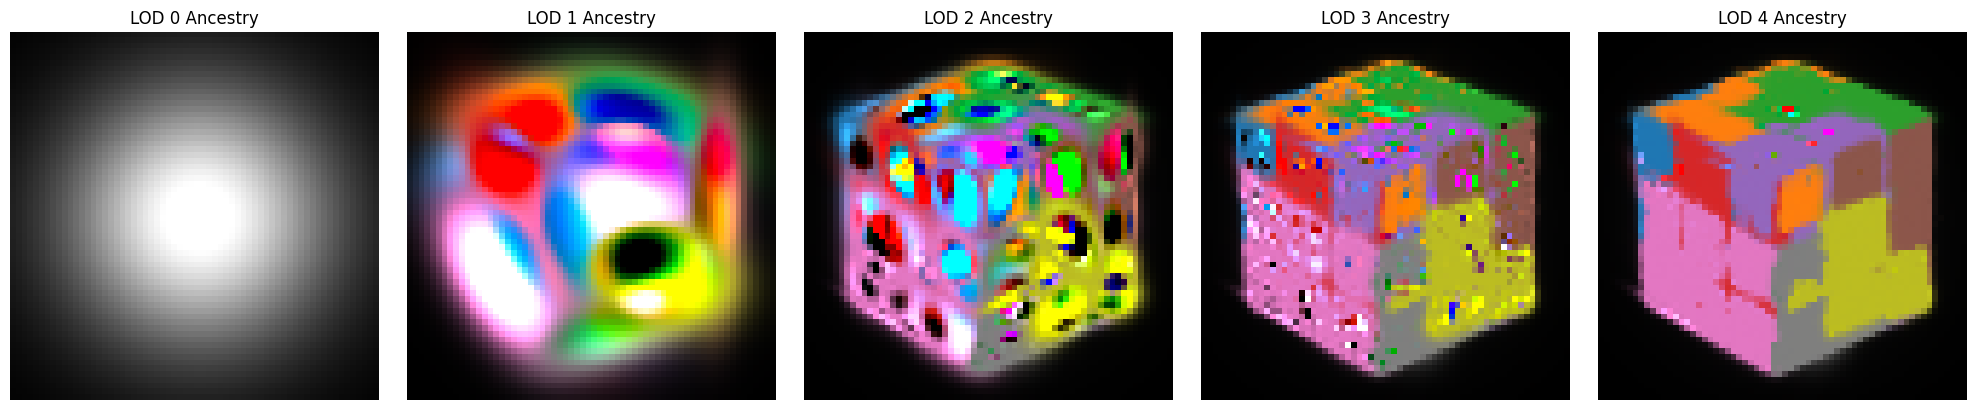

In [ ]:
import matplotlib.cm as cm

@torch.no_grad()
def visualize_tree_branches_64(model, renderer, max_lod=4):
    device = next(model.parameters()).device
    lods = model.get_lod_tensors()

    cmap = plt.get_cmap('tab10')
    branch_colors = torch.tensor([cmap(i)[:3] for i in range(9)], dtype=torch.float32, device=device)

    clamped_colors = torch.clamp(branch_colors, 1e-4, 1.0 - 1e-4)
    inv_sig_colors = torch.log(clamped_colors / (1.0 - clamped_colors))

    colored_lods = []
    for l, level_data in enumerate(lods):
        new_data = {k: v.clone() for k, v in level_data.items()}

        if l == 0:
            gray_logit = torch.log(torch.tensor([0.5 / (1.0 - 0.5)], device=device))
            new_data['color'] = torch.ones(1, 3, device=device) * gray_logit
        else:
            nodes_per_branch = 9**(l-1)
            branch_indices = torch.arange(9, device=device).view(9, 1).expand(9, nodes_per_branch).reshape(-1)
            new_data['color'] = inv_sig_colors[branch_indices]
            new_data['opacity'] = torch.ones_like(new_data['opacity']) * 5.0

        colored_lods.append(new_data)

    fig, axes = plt.subplots(1, max_lod + 1, figsize=(4 * (max_lod + 1), 4))
    for lod in range(max_lod + 1):
        # For the 64x64 version, we just render normally (no chunking needed)
        rgb, _ = renderer.render(colored_lods, lod)
        axes[lod].imshow(rgb.cpu().numpy())
        axes[lod].set_title(f"LOD {lod} Ancestry")
        axes[lod].axis('off')

    plt.tight_layout()
    plt.show()

print("Generating Ancestry Map for 64x64 Tanh Model...")
visualize_tree_branches_64(model, renderer, max_lod=4)

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image

def load_color_target_full(path):
    img = Image.open(path).convert("RGBA")
    img_t = T.ToTensor()(img)
    return img_t[:3].permute(1, 2, 0), img_t[3] # rgb, alpha

# --- Chunked Memory-Safe Renderer ---
class PatchColorTensorRenderer(ColorTensorRenderer):
    def get_frontier_tensors(self, lods, target_lod):
        frontiers = []
        current_prob = torch.ones(1, 1, device=self.device)
        for l in range(target_lod + 1):
            d = lods[l]
            prob_stop = current_prob if l == target_lod else current_prob * (1 - d['split_prob'])

            # Use .get('z') to safely handle both LOD 5 (with Z) and older high-res models (without Z)
            z_val = d.get('z', torch.zeros_like(d['rot']))
            frontiers.append({'mu': d['mu'], 'scale': d['scale'], 'rot': d['rot'], 'z': z_val, 'color': d['color'], 'opacity': d['opacity'], 'prob': prob_stop})

            if l < target_lod:
                current_prob = (current_prob * d['split_prob']).unsqueeze(1).expand(-1, 9, -1).reshape(-1, 1)

        mu = torch.cat([f['mu'] for f in frontiers], dim=0)
        scale = torch.cat([f['scale'] for f in frontiers], dim=0)
        rot = torch.cat([f['rot'] for f in frontiers], dim=0)
        z = torch.cat([f['z'] for f in frontiers], dim=0)
        color = torch.cat([f['color'] for f in frontiers], dim=0)
        opacity = torch.cat([f['opacity'] for f in frontiers], dim=0)
        prob = torch.cat([f['prob'] for f in frontiers], dim=0)
        return mu, scale, rot, z, color, opacity, prob

    def render_patch(self, lods, target_lod, sampled_coords, gaussian_chunk_size=1024):
        mu, scale, rot, z, color, opacity, prob = self.get_frontier_tensors(lods, target_lod)

        # Z-Sort first to ensure correct occlusion during accumulation
        indices = torch.argsort(z.view(-1), descending=True)
        mu, scale, rot, color, opacity, prob = mu[indices], scale[indices], rot[indices], color[indices], opacity[indices], prob[indices]

        N_gaussians = mu.shape[0]
        H_pixels = sampled_coords.shape[0]

        # Accumulators
        acc_rgb = torch.zeros((H_pixels, 3), device=self.device)
        acc_alpha = torch.zeros((H_pixels, 1), device=self.device)
        visibility = torch.ones((H_pixels, 1), device=self.device)

        # Process Gaussians in chunks to keep memory usage constant
        for i in range(0, N_gaussians, gaussian_chunk_size):
            end = min(i + gaussian_chunk_size, N_gaussians)
            m_c = mu[i:end] # (C, 2)
            s_c = scale[i:end] # (C, 2)
            r_c = rot[i:end] # (C, 1)
            c_c = torch.sigmoid(color[i:end]) # (C, 3)
            o_c = opacity[i:end] # (C, 1)
            p_c = prob[i:end] # (C, 1)

            # (C, H_pixels, 2)
            diff = sampled_coords.unsqueeze(0) - m_c.unsqueeze(1)
            cos_t, sin_t = torch.cos(r_c), torch.sin(r_c)

            rot_x = diff[:, :, 0] * cos_t - diff[:, :, 1] * sin_t
            rot_y = diff[:, :, 0] * sin_t + diff[:, :, 1] * cos_t
            dist_sq = (rot_x / (s_c[:, 0:1] + 1e-8))**2 + (rot_y / (s_c[:, 1:2] + 1e-8))**2

            # Alpha for this chunk: (C, H_pixels)
            alpha_chunk = (o_c * p_c) * torch.exp(-0.5 * dist_sq)

            # Update pixel colors and visibility iteratively (No inplace operations!)
            for j in range(alpha_chunk.shape[0]):
                a = alpha_chunk[j:j+1].t() # (H_pixels, 1)
                color_val = c_c[j:j+1] # (1, 3)

                acc_rgb = acc_rgb + visibility * a * color_val
                acc_alpha = acc_alpha + visibility * a
                visibility = visibility * (1.0 - a)

        return torch.clamp(acc_rgb, 0, 1), torch.clamp(acc_alpha.squeeze(), 0, 1)

    def render_full_image_chunked(self, lods, target_lod, chunk_size=32):
        H, W = self.image_size
        full_rgb = torch.zeros((H, W, 3), device=self.device)
        y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=self.device), torch.linspace(-1, 1, W, device=self.device), indexing='ij')

        with torch.no_grad():
            for y_s in range(0, H, chunk_size):
                for x_s in range(0, W, chunk_size):
                    y_e, x_e = min(y_s + chunk_size, H), min(x_s + chunk_size, W)
                    grid_chunk = torch.stack([x[y_s:y_e, x_s:x_e], y[y_s:y_e, x_s:x_e]], dim=-1).view(-1, 2)
                    rgb, _ = self.render_patch(lods, target_lod, grid_chunk)
                    full_rgb[y_s:y_e, x_s:x_e] = rgb.view(y_e-y_s, x_e-x_s, 3)
        return full_rgb

NameError: name 'ColorTensorRenderer' is not defined

Loaded full image at resolution: 500x500
Training with 6,561 Anisotropic Gaussians using Progressive Coarse-to-Fine Curriculum...
(Strict Spatial Bounds via Tanh Leash is ACTIVE)
--------------------------------------------------

--- Phase 1: Training at 64x64 ---
  Iter 200/400, Loss (on 4096 random pixels): 0.3708
  Iter 400/400, Loss (on 4096 random pixels): 0.3192

--- Phase 2: Training at 128x128 ---
  Iter 200/400, Loss (on 8192 random pixels): 0.3442
  Iter 400/400, Loss (on 8192 random pixels): 0.3140

--- Phase 3: Training at 256x256 ---
  Iter 200/400, Loss (on 8192 random pixels): 0.3252
  Iter 400/400, Loss (on 8192 random pixels): 0.5253

--- Phase 4: Training at 500x500 ---
  Iter 200/800, Loss (on 8192 random pixels): 0.3269
  Iter 400/800, Loss (on 8192 random pixels): 0.3080
  Iter 600/800, Loss (on 8192 random pixels): 0.3847
  Iter 800/800, Loss (on 8192 random pixels): 0.3004


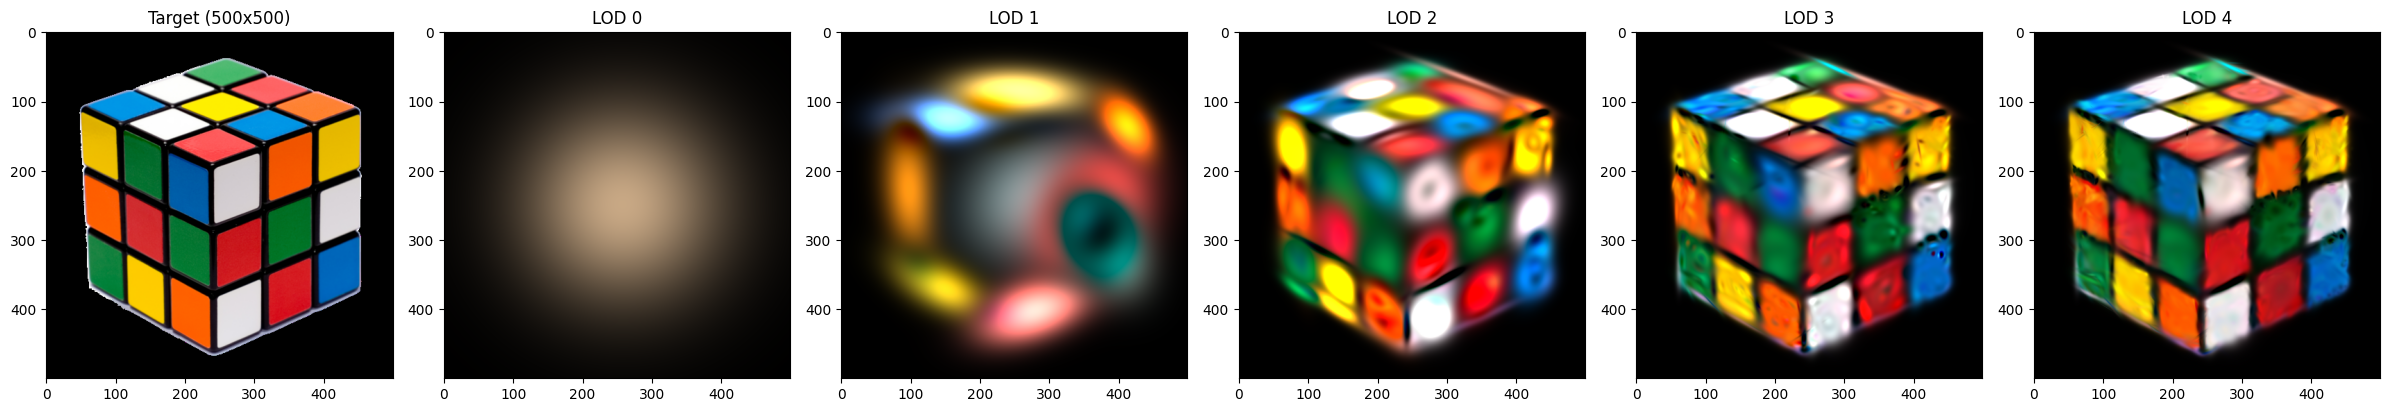

In [ ]:
# --- Progressive Curriculum Training Loop ---
def train_color_cube_progressive(target_rgb_full, target_a_full, num_samples=8192, device='cpu'):
    H_full, W_full = target_rgb_full.shape[:2]

    class ColorModel(nn.Module):
        def __init__(self, device):
            super().__init__()
            self.root_mu = nn.Parameter(torch.zeros(1, 2, device=device))
            self.root_scale = nn.Parameter(torch.ones(1, 2, device=device) * 0.5)
            self.root_rot = nn.Parameter(torch.zeros(1, 1, device=device))
            self.root_z = nn.Parameter(torch.zeros(1, 1, device=device))
            self.root_color = nn.Parameter(torch.zeros(1, 3, device=device))
            self.root_opacity = nn.Parameter(torch.ones(1, 1, device=device))
            self.root_split = nn.Parameter(torch.zeros(1, 1, device=device))
            self.refs = nn.ModuleList([ColorTensorRefinement(9**i, device=device) for i in range(4)])

        def get_lod_tensors(self):
            lods = [{'mu': self.root_mu, 'scale': self.root_scale, 'rot': self.root_rot, 'z': self.root_z, 'color': self.root_color, 'opacity': self.root_opacity, 'split_prob': torch.sigmoid(self.root_split)}]
            for ref in self.refs:
                p = lods[-1]
                lods.append(dict(zip(['mu','scale','rot','z','color','opacity','split_prob'], ref(p['mu'], p['scale'], p['rot'], p['z'], p['color'], p['opacity']))))
            return lods

    model = ColorModel(device).to(device)
    renderer = PatchColorTensorRenderer((H_full, W_full), device)
    optimizer = optim.Adam(model.parameters(), lr=0.03)

    # Setup Progressive Schedule
    resolutions = [(64, 64), (128, 128), (256, 256), (H_full, W_full)]
    iterations_per_stage = [400, 400, 400, 800]

    # Prepare tensors for interpolation (B, C, H, W)
    target_rgb_t = target_rgb_full.permute(2,0,1).unsqueeze(0)
    target_a_t = target_a_full.unsqueeze(0).unsqueeze(0)

    for stage, (H_s, W_s) in enumerate(resolutions):
        print(f"\n--- Phase {stage+1}: Training at {W_s}x{H_s} ---")

        # Downscale Target dynamically
        if H_s == H_full and W_s == W_full:
            stage_rgb = target_rgb_full
            stage_a = target_a_full
        else:
            stage_rgb = F.interpolate(target_rgb_t, size=(H_s, W_s), mode='bilinear', align_corners=False).squeeze(0).permute(1,2,0)
            stage_a = F.interpolate(target_a_t, size=(H_s, W_s), mode='bilinear', align_corners=False).squeeze()

        # Build coordinate grid for this resolution
        y_s, x_s = torch.meshgrid(torch.linspace(-1, 1, H_s, device=device), torch.linspace(-1, 1, W_s, device=device), indexing='ij')
        coords_flat = torch.stack([x_s, y_s], dim=-1).view(-1, 2)
        rgb_flat = stage_rgb.reshape(-1, 3)
        a_flat = stage_a.reshape(-1)

        total_pixels = H_s * W_s
        iters = iterations_per_stage[stage]

        for i in range(iters):
            optimizer.zero_grad()
            lods = model.get_lod_tensors()

            # Global Random Pixel Sampling
            samples_this_step = min(num_samples, total_pixels)
            indices = torch.randint(0, total_pixels, (samples_this_step,), device=device)

            sampled_target_rgb = rgb_flat[indices]
            sampled_target_a = a_flat[indices]
            sampled_coords = coords_flat[indices]

            total_loss = 0
            for lod in range(5):
                rgb, alpha = renderer.render_patch(lods, lod, sampled_coords)
                loss = F.mse_loss(rgb * sampled_target_a.unsqueeze(-1), sampled_target_rgb * sampled_target_a.unsqueeze(-1)) + F.mse_loss(alpha, sampled_target_a)
                total_loss += loss

            total_loss.backward()
            optimizer.step()

            if (i+1) % 200 == 0:
                print(f"  Iter {i+1}/{iters}, Loss (on {samples_this_step} random pixels): {total_loss.item():.4f}")

    return model, renderer

# --- Execution ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the full-sized image
t_rgb_full, t_a_full = load_color_target_full('/content/sample_data/rubik_cube.png')
H_full, W_full = t_rgb_full.shape[:2]
print(f"Loaded full image at resolution: {W_full}x{H_full}")
print(f"Training with 6,561 Anisotropic Gaussians using Progressive Coarse-to-Fine Curriculum...")
print(f"(Strict Spatial Bounds via Tanh Leash is ACTIVE)")
print("-" * 50)

# Train using progressive curriculum
model_full, renderer_full = train_color_cube_progressive(t_rgb_full.to(device), t_a_full.to(device), num_samples=8192, device=device)

# Visualize using chunked rendering
fig, axes = plt.subplots(1, 6, figsize=(24, 4))
axes[0].imshow(t_rgb_full.cpu().numpy())
axes[0].set_title(f"Target ({W_full}x{H_full})")

for lod in range(5):
    # Tile-by-tile rendering to avoid memory explosion
    rgb = renderer_full.render_full_image_chunked(model_full.get_lod_tensors(), lod, chunk_size=64)
    axes[lod+1].imshow(rgb.detach().cpu().numpy())
    axes[lod+1].set_title(f"LOD {lod}")

plt.tight_layout()
plt.show()

## Spatial Locality Visualization

This cell proves the strict spatial locality of the hierarchical tree. We override the learned colors by assigning a distinct color to each of the 9 root children (LOD 1). All of their descendants inherit this color.

Because of the multiplicative decay of `sigma`, the branches are mathematically restricted to local spatial patches and cannot "bleed" across the image.

Generating Ancestry Map...


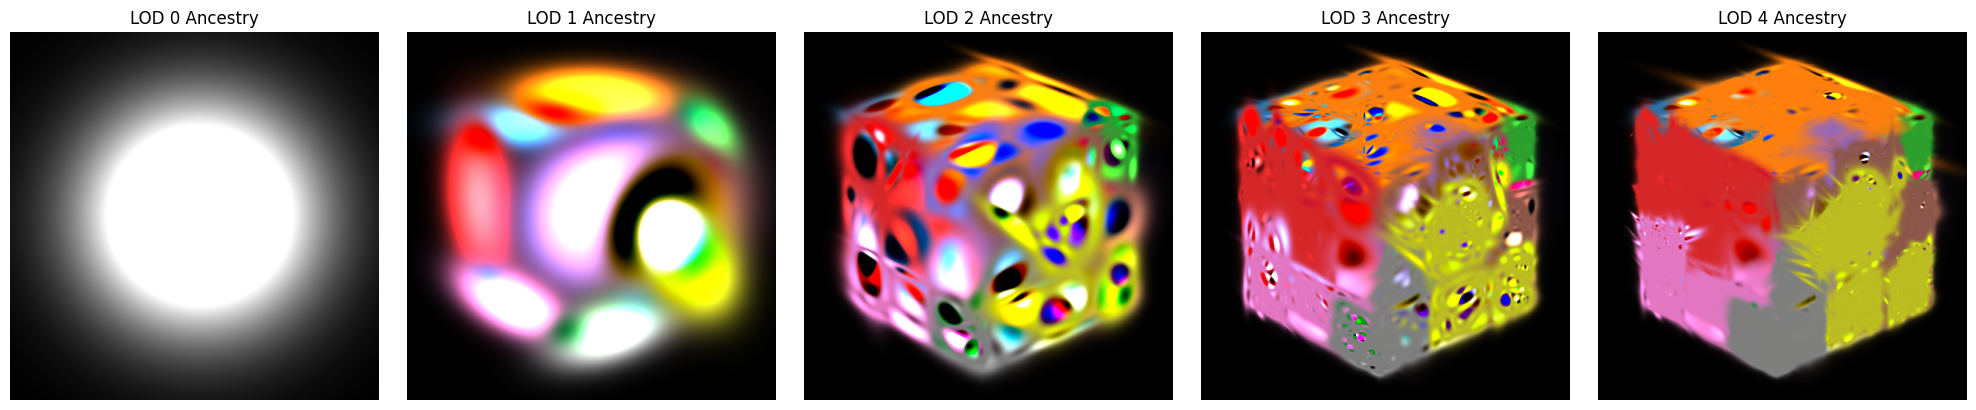

In [ ]:
import matplotlib.cm as cm

@torch.no_grad()
def visualize_tree_branches(model, renderer, max_lod=4):
    # Extract device from model parameters
    device = next(model.parameters()).device

    # 1. Get the current learned parameters for all levels
    lods = model.get_lod_tensors()

    # 2. Create a distinct 9-color palette (Tab10 has good distinct colors)
    cmap = plt.get_cmap('tab10')
    branch_colors = torch.tensor([cmap(i)[:3] for i in range(9)], dtype=torch.float32, device=device)

    # Convert target colors to logits (inverse sigmoid) because the renderer applies sigmoid at the end
    clamped_colors = torch.clamp(branch_colors, 1e-4, 1.0 - 1e-4)
    inv_sig_colors = torch.log(clamped_colors / (1.0 - clamped_colors))

    colored_lods = []
    for l, level_data in enumerate(lods):
        # Clone the dict so we don't accidentally modify the actual model parameters
        new_data = {k: v.clone() for k, v in level_data.items()}

        if l == 0:
            # LOD 0: Just a neutral gray root
            gray_logit = torch.log(torch.tensor([0.5 / (1.0 - 0.5)], device=device))
            new_data['color'] = torch.ones(1, 3, device=device) * gray_logit
        else:
            # Total nodes at this level: 9^l
            num_nodes = 9**l
            # Nodes per LOD 1 branch: 9^(l-1)
            nodes_per_branch = 9**(l-1)

            # Create an array that repeats the branch ID (0 to 8) for all descendants of that branch
            # Example at LOD 2: [0,0,0,0,0,0,0,0,0, 1,1,1,1,1,1,1,1,1, ..., 8,8,...]
            branch_indices = torch.arange(9, device=device).view(9, 1).expand(9, nodes_per_branch).reshape(-1)

            # Assign the inverse-sigmoid colors based on the branch ID
            new_data['color'] = inv_sig_colors[branch_indices]

            # Optional: Force opacity to be highly visible so we clearly see the footprints
            new_data['opacity'] = torch.ones_like(new_data['opacity']) * 5.0 # High logit for near 1.0 opacity

        colored_lods.append(new_data)

    # 3. Render and Plot
    fig, axes = plt.subplots(1, max_lod + 1, figsize=(4 * (max_lod + 1), 4))
    for lod in range(max_lod + 1):
        # Use our chunked renderer to avoid GPU OOM on the 500x500 canvas
        rgb = renderer.render_full_image_chunked(colored_lods, lod, chunk_size=64)
        axes[lod].imshow(rgb.cpu().numpy())
        axes[lod].set_title(f"LOD {lod} Ancestry")
        axes[lod].axis('off')

    plt.tight_layout()
    plt.show()

# Execute the visualization on our fully trained 500x500 model
print("Generating Ancestry Map...")
visualize_tree_branches(model_full, renderer_full, max_lod=4)

## Color LOD 4 Compression Analysis

Comparing the memory footprint of the Fully Fourier Compressed `ColorModel` versus the raw uncompressed image data.

In [ ]:
def analyze_storage(model, H, W):
    # 1. Raw Image Size (Uncompressed)
    num_pixels = H * W
    channels = 4 # RGBA

    # Standard image (1 byte per channel, 8-bit)
    raw_8bit_bytes = num_pixels * channels * 1

    # Uncompressed Tensor (4 bytes per channel, Float32)
    raw_32bit_bytes = num_pixels * channels * 4

    # 2. Model Size
    # Count all parameters in the Fourier-compressed model
    total_params = sum(p.numel() for p in model.parameters())
    model_bytes = total_params * 4 # PyTorch float32 uses 4 bytes per param

    # 3. Independent Parameter Equivalent (for context)
    # At LOD 4, we have 9^4 = 6561 Gaussians.
    # If stored independently (mu(2) + sigma(1) + rgb(3) + opacity(1) = 7 params per Gaussian)
    independent_params = (9**4) * 7
    independent_bytes = independent_params * 4

    print("="*50)
    print(" STORAGE SPACE ANALYSIS (LOD 4)")
    print("="*50)
    print(f"Raw Image (8-bit RGBA):      {raw_8bit_bytes / 1024:>7.2f} KB")
    print(f"Raw Tensor (32-bit float):   {raw_32bit_bytes / 1024:>7.2f} KB")
    print("-"*50)
    print(f"Fourier ColorModel (Float32):{model_bytes / 1024:>7.2f} KB  ({total_params} parameters)")
    print(f"Independent Gaussians (LOD 4):{independent_bytes / 1024:>7.2f} KB  ({independent_params} parameters)")
    print("="*50)
    print(" COMPRESSION RATIOS")
    print("="*50)
    print(f"Model vs. 8-bit Raw Image:   {raw_8bit_bytes / model_bytes:>5.2f}x smaller")
    print(f"Model vs. 32-bit Raw Tensor: {raw_32bit_bytes / model_bytes:>5.2f}x smaller")
    print(f"Fourier vs. Indep. Gaussians:{independent_bytes / model_bytes:>5.2f}x smaller")
    print("="*50)

# Run the analysis
analyze_storage(model, H, W)

 STORAGE SPACE ANALYSIS (LOD 4)
Raw Image (8-bit RGBA):        16.00 KB
Raw Tensor (32-bit float):     64.00 KB
--------------------------------------------------
Fourier ColorModel (Float32):  12.70 KB  (3250 parameters)
Independent Gaussians (LOD 4): 179.40 KB  (45927 parameters)
 COMPRESSION RATIOS
Model vs. 8-bit Raw Image:    1.26x smaller
Model vs. 32-bit Raw Tensor:  5.04x smaller
Fourier vs. Indep. Gaussians:14.13x smaller


## Alternative Experiment: Low-Rank Matrix Decomposition

Instead of using sine and cosine waves (Fourier features) to determine how a Gaussian splits, this experiment uses a **Low-Rank Matrix Factorization** ($U \times V$).

This creates an information bottleneck. By forcing the mapping matrix to have a low rank (e.g., Rank = 4), the model must learn a dictionary of the 4 most fundamental "splitting patterns" necessary to recreate the image, and then assign a linear combination of those patterns to each parent node.

Training Low-Rank Matrix Model (Rank 4) with Z-Depth and LOD 5...
Iter 0, Loss: 1.7429
Iter 100, Loss: 0.4722
Iter 200, Loss: 0.4079
Iter 300, Loss: 0.4058


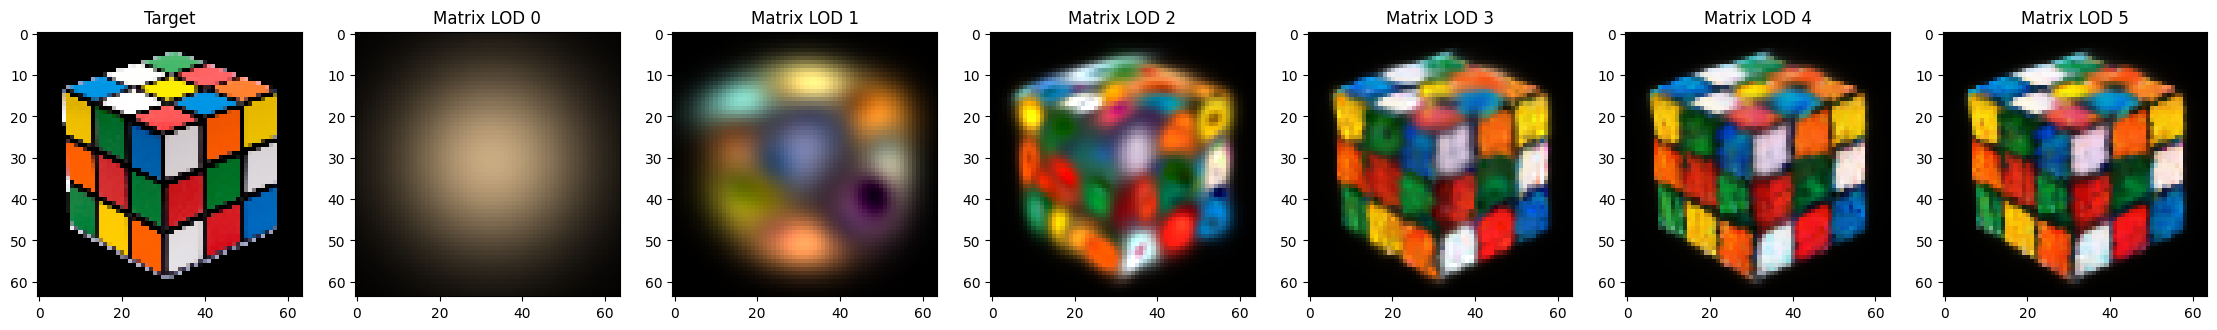

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Low-Rank Matrix Refinement Module ---
class MatrixTensorRefinement(nn.Module):
    def __init__(self, rank=4, device='cpu'):
        super().__init__()
        self.device = device
        self.rank = rank

        # Inputs from parent: mu(2), scale(2), rot(1), z(1), color(3), opacity(1) = 10
        self.in_features = 10
        # Outputs per child: mu(2), scale(2), rot(1), z(1), color(3), a(1), q(1) = 11
        self.out_features_per_child = 11
        self.num_children = 9
        self.total_out = self.num_children * self.out_features_per_child # 99 total outputs

        # The Bottleneck Matrices (U and V)
        self.U = nn.Parameter(torch.randn(self.in_features, self.rank, device=device) * 0.1)
        self.V = nn.Parameter(torch.randn(self.rank, self.total_out, device=device) * 0.1)
        self.bias = nn.Parameter(torch.zeros(self.total_out, device=device))

        offset = math.sqrt(2.0 / 3.0)
        base_delta = torch.tensor([
            [-offset, -offset], [ 0.0, -offset], [ offset, -offset],
            [-offset,  0.0],    [ 0.0,  0.0],    [ offset,  0.0],
            [-offset,  offset], [ 0.0,  offset], [ offset,  offset]
        ], device=device)
        self.register_buffer('base_Delta', base_delta)

        # Initialize specific bias terms to match the "shrinking" baseline
        with torch.no_grad():
            out_view = self.bias.view(self.num_children, self.out_features_per_child)
            out_view[:, 2:4] = math.log(1.0 / 3.0) # Delta scale starts at 1/3 shrinkage
            out_view[:, 9:10] = 3.0                # Opacity retention gate starts high

    def forward(self, mu, scale, rot, z, color, opacity):
        N = mu.shape[0]

        # 1. Concatenate parent state into a single feature vector
        parent_features = torch.cat([mu, scale, rot, z, color, opacity], dim=1) # (N, 10)

        # 2. Linear projection through the Low-Rank Bottleneck
        latent = torch.matmul(parent_features, self.U)        # (N, 10) @ (10, 4) -> (N, 4)
        out = torch.matmul(latent, self.V) + self.bias        # (N, 4) @ (4, 99) -> (N, 99)
        out = out.view(N, self.num_children, self.out_features_per_child)

        # 3. Slice out the specific parameter deltas
        res_mu = torch.tanh(out[:, :, 0:2])
        delta_scale = out[:, :, 2:4]
        delta_rot = out[:, :, 4:5]
        delta_z = out[:, :, 5:6]
        delta_rgb = out[:, :, 6:9]
        a = out[:, :, 9:10]
        q = out[:, :, 10:11]

        # 4. Apply deltas to parent to spawn children
        avg_scale = scale.mean(dim=-1, keepdim=True)
        mu_child = mu.unsqueeze(1) + avg_scale.unsqueeze(1) * (self.base_Delta + res_mu)
        scale_child = scale.unsqueeze(1) * torch.exp(delta_scale)
        rot_child = rot.unsqueeze(1) + delta_rot
        z_child = z.unsqueeze(1) + delta_z
        color_child = color.unsqueeze(1) + delta_rgb
        opacity_child = opacity.unsqueeze(1) * torch.sigmoid(a)
        split_prob_child = torch.sigmoid(q)

        N_new = N * 9
        return (
            mu_child.reshape(N_new, 2), scale_child.reshape(N_new, 2), rot_child.reshape(N_new, 1),
            z_child.reshape(N_new, 1), color_child.reshape(N_new, 3), opacity_child.reshape(N_new, 1), split_prob_child.reshape(N_new, 1)
        )

# --- Unified Matrix Model ---
class MatrixColorModel(nn.Module):
    def __init__(self, rank=4, device='cpu'):
        super().__init__()
        self.root_mu = nn.Parameter(torch.zeros(1, 2, device=device))
        self.root_scale = nn.Parameter(torch.ones(1, 2, device=device) * 0.5)
        self.root_rot = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_z = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_color = nn.Parameter(torch.zeros(1, 3, device=device))
        self.root_opacity = nn.Parameter(torch.ones(1, 1, device=device))
        self.root_split = nn.Parameter(torch.zeros(1, 1, device=device))

        # 5 levels of depth using Matrix Refinement
        self.refs = nn.ModuleList([MatrixTensorRefinement(rank=rank, device=device) for _ in range(5)])

    def get_lod_tensors(self):
        lods = [{'mu': self.root_mu, 'scale': self.root_scale, 'rot': self.root_rot, 'z': self.root_z, 'color': self.root_color, 'opacity': self.root_opacity, 'split_prob': torch.sigmoid(self.root_split)}]
        for ref in self.refs:
            p = lods[-1]
            lods.append(dict(zip(['mu','scale','rot','z','color','opacity','split_prob'], ref(p['mu'], p['scale'], p['rot'], p['z'], p['color'], p['opacity']))))
        return lods

# --- Execution & Training ---
def train_matrix_cube(target_rgb, target_a, iterations=400, device='cpu'):
    print(f"Training Low-Rank Matrix Model (Rank 4) with Z-Depth and LOD 5...")
    H, W = target_rgb.shape[:2]

    model = MatrixColorModel(rank=4, device=device).to(device)
    renderer = PatchColorTensorRenderer((H, W), device)
    optimizer = optim.Adam(model.parameters(), lr=0.02)

    y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
    coords_flat = torch.stack([x, y], dim=-1).view(-1, 2)
    target_rgb_flat = target_rgb.reshape(-1, 3)
    target_a_flat = target_a.reshape(-1)

    num_samples = 1024 # Keeping our memory-safe sampling limit

    for i in range(iterations):
        optimizer.zero_grad()
        lods = model.get_lod_tensors()

        indices = torch.randint(0, H*W, (num_samples,), device=device)
        s_coords = coords_flat[indices]
        s_rgb = target_rgb_flat[indices]
        s_a = target_a_flat[indices]

        total_loss = 0
        for lod in range(6):
            rgb, alpha = renderer.render_patch(lods, lod, s_coords)
            loss = F.mse_loss(rgb * s_a.unsqueeze(-1), s_rgb * s_a.unsqueeze(-1)) + F.mse_loss(alpha, s_a)
            total_loss += loss

        total_loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Iter {i}, Loss: {total_loss.item():.4f}")
            torch.cuda.empty_cache()

    return model, renderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Safely load the full image and downscale to 64x64 for this fast experiment
t_rgb_full, t_a_full = load_color_target_full('/content/sample_data/rubik_cube.png')
t_rgb_64 = F.interpolate(t_rgb_full.permute(2,0,1).unsqueeze(0), size=(64,64), mode='bilinear', align_corners=False).squeeze(0).permute(1,2,0)
t_a_64 = F.interpolate(t_a_full.unsqueeze(0).unsqueeze(0), size=(64,64), mode='bilinear', align_corners=False).squeeze()

model_matrix, renderer_matrix = train_matrix_cube(t_rgb_64.to(device), t_a_64.to(device), device=device)

fig, axes = plt.subplots(1, 7, figsize=(28, 4))
axes[0].imshow(t_rgb_64.cpu()); axes[0].set_title("Target")
for lod in range(6):
    rgb = renderer_matrix.render_full_image_chunked(model_matrix.get_lod_tensors(), lod, chunk_size=16)
    axes[lod+1].imshow(rgb.detach().cpu()); axes[lod+1].set_title(f"Matrix LOD {lod}")
plt.show()

## Alternative Experiment: Gabor Filter Refinement

This experiment replaces the global radial Fourier features with a learned bank of **Gabor Filters**. A Gabor filter is a sinusoidal wave enveloped by a Gaussian window.

By giving the model a set of localized frequencies (with learnable centers, scales, and wave vectors), the branching logic can respond to local texture requirements (like sharp edges in one specific corner of the image) without forcing that wave to ripple symmetrically across the entire canvas.

Training Gabor Filter Model (16 Localized Frequencies) with Z-Depth and LOD 5...
Iter 0, Loss: 1.7643
Iter 100, Loss: 0.4521
Iter 200, Loss: 0.3769
Iter 300, Loss: 0.3775


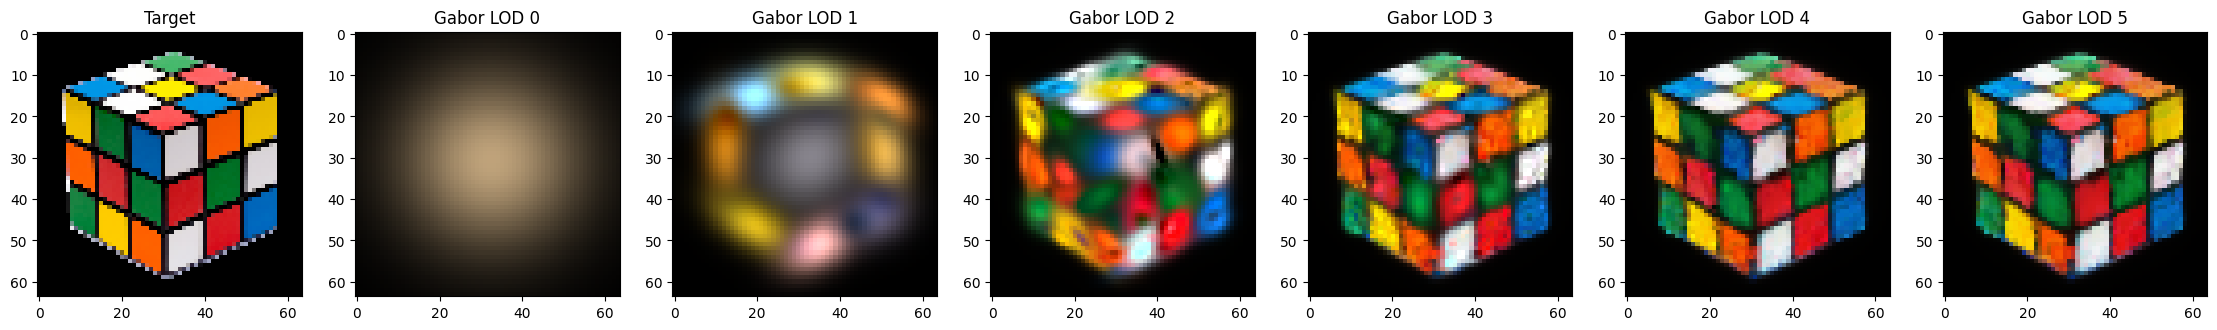

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Gabor Refinement Module ---
class GaborTensorRefinement(nn.Module):
    def __init__(self, num_filters=16, device='cpu'):
        super().__init__()
        self.device = device
        self.num_filters = num_filters
        self.num_children = 9

        # Learnable Gabor filter parameters
        self.gabor_centers = nn.Parameter(torch.rand(num_filters, 2, device=device) * 2 - 1) # [-1, 1]
        self.gabor_sigmas = nn.Parameter(torch.ones(num_filters, device=device) * 0.5)
        self.gabor_freqs = nn.Parameter(torch.randn(num_filters, 2, device=device) * 3.0)
        self.gabor_phases = nn.Parameter(torch.rand(num_filters, device=device) * 2 * math.pi)

        offset = math.sqrt(2.0 / 3.0)
        base_delta = torch.tensor([
            [-offset, -offset], [ 0.0, -offset], [ offset, -offset],
            [-offset,  0.0],    [ 0.0,  0.0],    [ offset,  0.0],
            [-offset,  offset], [ 0.0,  offset], [ offset,  offset]
        ], device=device)
        self.register_buffer('base_Delta', base_delta)

        # Output projection weights (num_filters + 1 for the DC/bias term)
        num_features = num_filters + 1
        self.weight_mu = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.weight_scale = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.weight_rot = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_z = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_rgb = nn.Parameter(torch.zeros(num_features, 9, 3, device=device))
        self.weight_a = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_q = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))

        # Initialize DC terms (constant base values)
        with torch.no_grad():
            self.weight_scale[0, :, :] = math.log(1.0 / 3.0)
            self.weight_a[0, :, 0] = 3.0

    def forward(self, mu, scale, rot, z, color, opacity):
        N = mu.shape[0]

        # 1. Compute Gabor Features for each parent position
        diff = mu.unsqueeze(1) - self.gabor_centers.unsqueeze(0) # (N, F, 2)
        dist_sq = (diff ** 2).sum(dim=-1) # (N, F)

        # Gaussian envelope (localizer)
        env = torch.exp(-dist_sq / (2 * self.gabor_sigmas.unsqueeze(0)**2 + 1e-8))

        # Sinusoidal wave (frequency)
        wave_arg = (diff * self.gabor_freqs.unsqueeze(0)).sum(dim=-1) + self.gabor_phases.unsqueeze(0)
        wave = torch.cos(wave_arg)

        # Gabor response: Windowed wave
        gabor_response = env * wave # (N, F)

        # Append DC term (constant 1.0) so base transformations can still happen
        dc_term = torch.ones(N, 1, device=self.device)
        F_basis = torch.cat([dc_term, gabor_response], dim=1) # (N, F+1)

        # 2. Project Gabor features into parameter deltas
        res_mu = torch.tanh(torch.einsum('nf, fcd -> ncd', F_basis, self.weight_mu))
        delta_scale = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_scale)
        delta_rot = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_rot)
        delta_z = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_z)
        delta_rgb = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_rgb)
        a = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_a)
        q = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_q)

        # 3. Apply deltas to parent to spawn children
        avg_scale = scale.mean(dim=-1, keepdim=True)
        mu_child = mu.unsqueeze(1) + avg_scale.unsqueeze(1) * (self.base_Delta + res_mu)
        scale_child = scale.unsqueeze(1) * torch.exp(delta_scale)
        rot_child = rot.unsqueeze(1) + delta_rot
        z_child = z.unsqueeze(1) + delta_z
        color_child = color.unsqueeze(1) + delta_rgb
        opacity_child = opacity.unsqueeze(1) * torch.sigmoid(a)
        split_prob_child = torch.sigmoid(q)

        N_new = N * 9
        return (
            mu_child.reshape(N_new, 2), scale_child.reshape(N_new, 2), rot_child.reshape(N_new, 1),
            z_child.reshape(N_new, 1), color_child.reshape(N_new, 3), opacity_child.reshape(N_new, 1), split_prob_child.reshape(N_new, 1)
        )

# --- Unified Gabor Model ---
class GaborColorModel(nn.Module):
    def __init__(self, num_filters=16, device='cpu'):
        super().__init__()
        self.root_mu = nn.Parameter(torch.zeros(1, 2, device=device))
        self.root_scale = nn.Parameter(torch.ones(1, 2, device=device) * 0.5)
        self.root_rot = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_z = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_color = nn.Parameter(torch.zeros(1, 3, device=device))
        self.root_opacity = nn.Parameter(torch.ones(1, 1, device=device))
        self.root_split = nn.Parameter(torch.zeros(1, 1, device=device))

        # 5 levels of depth using Gabor Refinement
        self.refs = nn.ModuleList([GaborTensorRefinement(num_filters=num_filters, device=device) for _ in range(5)])

    def get_lod_tensors(self):
        lods = [{'mu': self.root_mu, 'scale': self.root_scale, 'rot': self.root_rot, 'z': self.root_z, 'color': self.root_color, 'opacity': self.root_opacity, 'split_prob': torch.sigmoid(self.root_split)}]
        for ref in self.refs:
            p = lods[-1]
            lods.append(dict(zip(['mu','scale','rot','z','color','opacity','split_prob'], ref(p['mu'], p['scale'], p['rot'], p['z'], p['color'], p['opacity']))))
        return lods

# --- Execution & Training ---
def train_gabor_cube(target_rgb, target_a, iterations=400, device='cpu'):
    print(f"Training Gabor Filter Model (16 Localized Frequencies) with Z-Depth and LOD 5...")
    H, W = target_rgb.shape[:2]

    model = GaborColorModel(num_filters=16, device=device).to(device)
    renderer = PatchColorTensorRenderer((H, W), device)
    optimizer = optim.Adam(model.parameters(), lr=0.02)

    y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
    coords_flat = torch.stack([x, y], dim=-1).view(-1, 2)
    target_rgb_flat = target_rgb.reshape(-1, 3)
    target_a_flat = target_a.reshape(-1)

    num_samples = 1024 # Memory-safe sampling

    for i in range(iterations):
        optimizer.zero_grad()
        lods = model.get_lod_tensors()

        indices = torch.randint(0, H*W, (num_samples,), device=device)
        s_coords = coords_flat[indices]
        s_rgb = target_rgb_flat[indices]
        s_a = target_a_flat[indices]

        total_loss = 0
        for lod in range(6):
            rgb, alpha = renderer.render_patch(lods, lod, s_coords)
            loss = F.mse_loss(rgb * s_a.unsqueeze(-1), s_rgb * s_a.unsqueeze(-1)) + F.mse_loss(alpha, s_a)
            total_loss += loss

        total_loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Iter {i}, Loss: {total_loss.item():.4f}")
            torch.cuda.empty_cache()

    return model, renderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Using the safely loaded and downscaled 64x64 target
model_gabor, renderer_gabor = train_gabor_cube(t_rgb_64.to(device), t_a_64.to(device), device=device)

fig, axes = plt.subplots(1, 7, figsize=(28, 4))
axes[0].imshow(t_rgb_64.cpu()); axes[0].set_title("Target")
for lod in range(6):
    rgb = renderer_gabor.render_full_image_chunked(model_gabor.get_lod_tensors(), lod, chunk_size=16)
    axes[lod+1].imshow(rgb.detach().cpu()); axes[lod+1].set_title(f"Gabor LOD {lod}")
plt.show()

## Alternative Experiment: Node-Centric Radial Gabor

Unlike the global Cartesian Gabor bank, this approach restores the "fractal" or relative nature of the hierarchy. Each node evaluates its own polar coordinates $(r, \theta)$:
*   **Gaussian Envelope:** Applied along the radius $r$. The model learns "rings" of activity (e.g., a filter might only activate for nodes exactly 0.5 units away from the center).
*   **Sinusoidal Wave:** Applied along the angle $\theta$ (just like the original Fourier features).

This allows the model to learn localized, high-frequency angular details without forcing those ripples to span the entire radial distance of the image.

Training Node-Centric Gabor Model (24 Radial Filters) with Z-Depth and LOD 5...
Iter 0, Loss: 1.7793
Iter 100, Loss: 0.4148
Iter 200, Loss: 0.3731
Iter 300, Loss: 0.3520


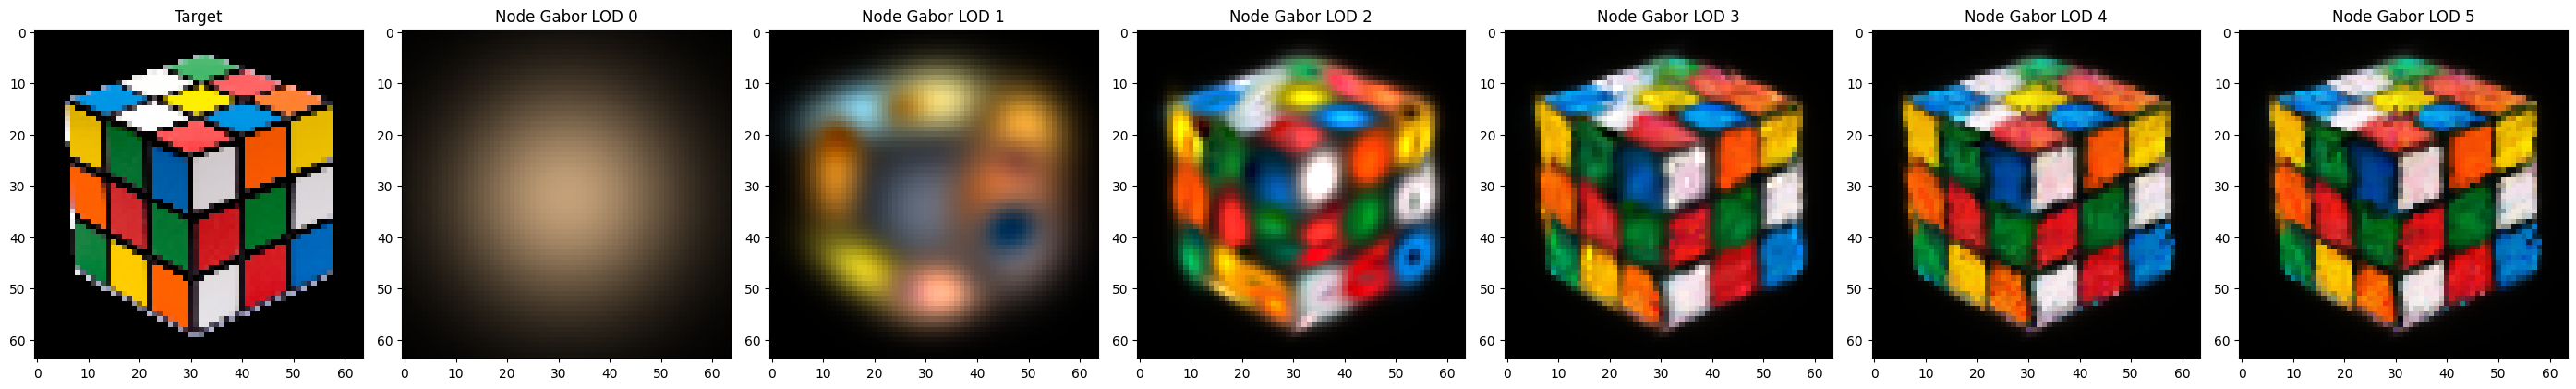

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Node-Centric Gabor Refinement Module ---
class NodeCentricGaborRefinement(nn.Module):
    def __init__(self, num_filters=16, device='cpu'):
        super().__init__()
        self.device = device
        self.num_filters = num_filters
        self.num_children = 9

        # Learnable Node-Centric Gabor parameters
        self.gabor_radii = nn.Parameter(torch.rand(num_filters, device=device) * 1.5) # Center of the envelope in r-space
        self.gabor_sigmas = nn.Parameter(torch.ones(num_filters, device=device) * 0.3) # Width of the radial envelope
        self.gabor_freqs = nn.Parameter(torch.randn(num_filters, device=device) * 4.0) # Angular frequency
        self.gabor_phases = nn.Parameter(torch.rand(num_filters, device=device) * 2 * math.pi) # Phase shift

        offset = math.sqrt(2.0 / 3.0)
        base_delta = torch.tensor([
            [-offset, -offset], [ 0.0, -offset], [ offset, -offset],
            [-offset,  0.0],    [ 0.0,  0.0],    [ offset,  0.0],
            [-offset,  offset], [ 0.0,  offset], [ offset,  offset]
        ], device=device)
        self.register_buffer('base_Delta', base_delta)

        # Output projection weights (num_filters + 1 for the DC/bias term)
        num_features = num_filters + 1
        self.weight_mu = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.weight_scale = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.weight_rot = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_z = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_rgb = nn.Parameter(torch.zeros(num_features, 9, 3, device=device))
        self.weight_a = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_q = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))

        # Initialize DC terms (constant base values)
        with torch.no_grad():
            self.weight_scale[0, :, :] = math.log(1.0 / 3.0)
            self.weight_a[0, :, 0] = 3.0

    def forward(self, mu, scale, rot, z, color, opacity):
        N = mu.shape[0]

        # 1. Compute Node-Centric Polar Coordinates
        r = torch.norm(mu, dim=-1, keepdim=True) # (N, 1)
        theta = torch.atan2(mu[:, 1], mu[:, 0]).unsqueeze(1) # (N, 1)

        # 2. Compute Radial Gabor Features
        # Radial Gaussian envelope (localizes the effect to a specific distance from center)
        env = torch.exp(-((r - self.gabor_radii.unsqueeze(0))**2) / (2 * self.gabor_sigmas.unsqueeze(0)**2 + 1e-8)) # (N, F)

        # Angular Sinusoidal wave (frequency details around the circle)
        wave = torch.cos(theta * self.gabor_freqs.unsqueeze(0) + self.gabor_phases.unsqueeze(0)) # (N, F)

        # Node-Centric Gabor response
        gabor_response = env * wave # (N, F)

        # Append DC term (constant 1.0)
        dc_term = torch.ones(N, 1, device=self.device)
        F_basis = torch.cat([dc_term, gabor_response], dim=1) # (N, F+1)

        # 3. Project features into parameter deltas
        res_mu = torch.tanh(torch.einsum('nf, fcd -> ncd', F_basis, self.weight_mu))
        delta_scale = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_scale)
        delta_rot = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_rot)
        delta_z = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_z)
        delta_rgb = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_rgb)
        a = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_a)
        q = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_q)

        # 4. Apply deltas to parent to spawn children
        avg_scale = scale.mean(dim=-1, keepdim=True)
        mu_child = mu.unsqueeze(1) + avg_scale.unsqueeze(1) * (self.base_Delta + res_mu)
        scale_child = scale.unsqueeze(1) * torch.exp(delta_scale)
        rot_child = rot.unsqueeze(1) + delta_rot
        z_child = z.unsqueeze(1) + delta_z
        color_child = color.unsqueeze(1) + delta_rgb
        opacity_child = opacity.unsqueeze(1) * torch.sigmoid(a)
        split_prob_child = torch.sigmoid(q)

        N_new = N * 9
        return (
            mu_child.reshape(N_new, 2), scale_child.reshape(N_new, 2), rot_child.reshape(N_new, 1),
            z_child.reshape(N_new, 1), color_child.reshape(N_new, 3), opacity_child.reshape(N_new, 1), split_prob_child.reshape(N_new, 1)
        )

# --- Unified Node-Centric Model ---
class NodeCentricGaborColorModel(nn.Module):
    def __init__(self, num_filters=24, device='cpu'):
        super().__init__()
        self.root_mu = nn.Parameter(torch.zeros(1, 2, device=device))
        self.root_scale = nn.Parameter(torch.ones(1, 2, device=device) * 0.5)
        self.root_rot = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_z = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_color = nn.Parameter(torch.zeros(1, 3, device=device))
        self.root_opacity = nn.Parameter(torch.ones(1, 1, device=device))
        self.root_split = nn.Parameter(torch.zeros(1, 1, device=device))

        # 5 levels of depth
        self.refs = nn.ModuleList([NodeCentricGaborRefinement(num_filters=num_filters, device=device) for _ in range(5)])

    def get_lod_tensors(self):
        lods = [{'mu': self.root_mu, 'scale': self.root_scale, 'rot': self.root_rot, 'z': self.root_z, 'color': self.root_color, 'opacity': self.root_opacity, 'split_prob': torch.sigmoid(self.root_split)}]
        for ref in self.refs:
            p = lods[-1]
            lods.append(dict(zip(['mu','scale','rot','z','color','opacity','split_prob'], ref(p['mu'], p['scale'], p['rot'], p['z'], p['color'], p['opacity']))))
        return lods

# --- Execution & Training ---
def train_node_gabor_cube(target_rgb, target_a, iterations=400, device='cpu'):
    print(f"Training Node-Centric Gabor Model (24 Radial Filters) with Z-Depth and LOD 5...")
    H, W = target_rgb.shape[:2]

    model = NodeCentricGaborColorModel(num_filters=24, device=device).to(device)
    renderer = PatchColorTensorRenderer((H, W), device)
    optimizer = optim.Adam(model.parameters(), lr=0.02)

    y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
    coords_flat = torch.stack([x, y], dim=-1).view(-1, 2)
    target_rgb_flat = target_rgb.reshape(-1, 3)
    target_a_flat = target_a.reshape(-1)

    num_samples = 1024 # Memory-safe sampling

    for i in range(iterations):
        optimizer.zero_grad()
        lods = model.get_lod_tensors()

        indices = torch.randint(0, H*W, (num_samples,), device=device)
        s_coords = coords_flat[indices]
        s_rgb = target_rgb_flat[indices]
        s_a = target_a_flat[indices]

        total_loss = 0
        for lod in range(6):
            rgb, alpha = renderer.render_patch(lods, lod, s_coords)
            loss = F.mse_loss(rgb * s_a.unsqueeze(-1), s_rgb * s_a.unsqueeze(-1)) + F.mse_loss(alpha, s_a)
            total_loss += loss

        total_loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Iter {i}, Loss: {total_loss.item():.4f}")
            torch.cuda.empty_cache()

    return model, renderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Using the 64x64 target tensor that is already loaded in the namespace
model_node_gabor, renderer_node_gabor = train_node_gabor_cube(t_rgb_64.to(device), t_a_64.to(device), device=device)

fig, axes = plt.subplots(1, 7, figsize=(28, 4))
axes[0].imshow(t_rgb_64.cpu()); axes[0].set_title("Target")
for lod in range(6):
    rgb = renderer_node_gabor.render_full_image_chunked(model_node_gabor.get_lod_tensors(), lod, chunk_size=16)
    axes[lod+1].imshow(rgb.detach().cpu()); axes[lod+1].set_title(f"Node Gabor LOD {lod}")
plt.tight_layout()
plt.show()

## Alternative Experiment: True Recurrent IFS (Iterated Function System)

In a true fractal or IFS, the exact same geometric rules apply at every level of depth. This experiment modifies the Node-Centric Gabor approach to be a pure IFS:
1. **Recurrent Weight Sharing:** A single refinement module is applied recursively across all 5 LODs, drastically reducing the parameter count.
2. **State-Aware Splitting:** The Gabor filter evaluation is concatenated with the parent's current `scale`, `rotation`, and `color`. This allows the single shared rule to adapt its behavior dynamically based on the parent's localized coordinate frame.

Training True Recurrent IFS Model (4 Shared Filters) with Z-Depth and LOD 5...
Iter 100, Loss: 0.5215
Iter 200, Loss: 0.4823
Iter 300, Loss: 0.4448
Iter 400, Loss: 0.4657
Iter 500, Loss: 0.4348
Iter 600, Loss: 0.4439
Iter 700, Loss: 0.4111
Iter 800, Loss: 0.4003
Iter 900, Loss: 0.4229
Iter 1000, Loss: 0.4553


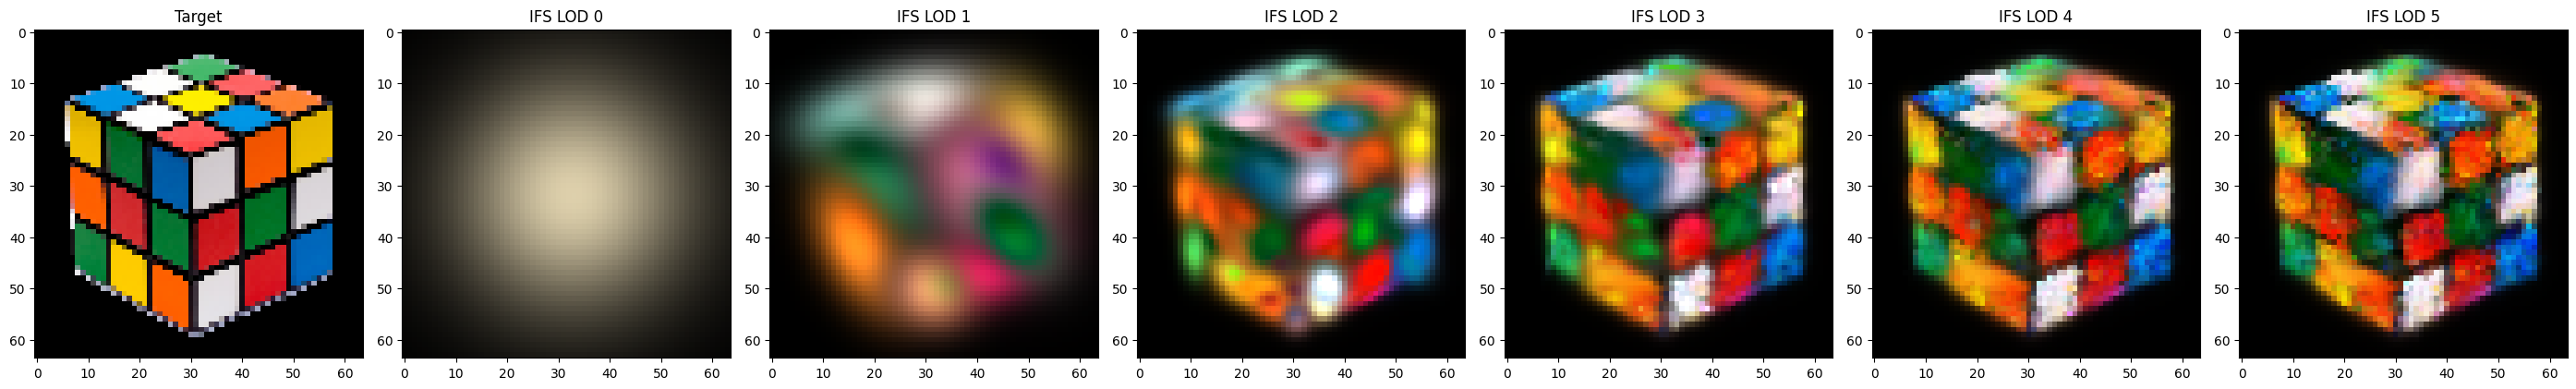

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# --- True IFS Recurrent Refinement Module ---
class TrueIFSRefinement(nn.Module):
    def __init__(self, num_filters=24, device='cpu'):
        super().__init__()
        self.device = device
        self.num_filters = num_filters
        self.num_children = 9

        # Learnable Node-Centric Gabor parameters
        self.gabor_radii = nn.Parameter(torch.rand(num_filters, device=device) * 1.5)
        self.gabor_sigmas = nn.Parameter(torch.ones(num_filters, device=device) * 0.3)
        self.gabor_freqs = nn.Parameter(torch.randn(num_filters, device=device) * 4.0)
        self.gabor_phases = nn.Parameter(torch.rand(num_filters, device=device) * 2 * math.pi)

        offset = math.sqrt(2.0 / 3.0)
        base_delta = torch.tensor([
            [-offset, -offset], [ 0.0, -offset], [ offset, -offset],
            [-offset,  0.0],    [ 0.0,  0.0],    [ offset,  0.0],
            [-offset,  offset], [ 0.0,  offset], [ offset,  offset]
        ], device=device)
        self.register_buffer('base_Delta', base_delta)

        # Features: DC(1) + Gabor(F) + Scale(2) + Rot(1) + Color(3) = F + 7
        num_features = num_filters + 7

        self.weight_mu = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.weight_scale = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.weight_rot = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_z = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_rgb = nn.Parameter(torch.zeros(num_features, 9, 3, device=device))
        self.weight_a = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_q = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))

        # Initialize DC terms (index 0) for stable base values
        with torch.no_grad():
            self.weight_scale[0, :, :] = math.log(1.0 / 3.0)
            self.weight_a[0, :, 0] = 3.0

    def forward(self, mu, scale, rot, z, color, opacity):
        N = mu.shape[0]

        # 1. Compute Spatial Gabor Features based on parent's position
        r = torch.norm(mu, dim=-1, keepdim=True) # (N, 1)
        theta = torch.atan2(mu[:, 1], mu[:, 0]).unsqueeze(1) # (N, 1)

        env = torch.exp(-((r - self.gabor_radii.unsqueeze(0))**2) / (2 * self.gabor_sigmas.unsqueeze(0)**2 + 1e-8))
        wave = torch.cos(theta * self.gabor_freqs.unsqueeze(0) + self.gabor_phases.unsqueeze(0))
        gabor_response = env * wave # (N, F)

        # 2. State-Aware Concatenation (The IFS Context)
        dc_term = torch.ones(N, 1, device=self.device)

        # PREVENT RECURRENT EXPLOSION: Bound the feedback state so it stays stable across 5 recursive jumps
        safe_scale = torch.tanh(scale)
        safe_rot = torch.sin(rot)
        safe_color = torch.tanh(color)

        F_basis = torch.cat([dc_term, gabor_response, safe_scale, safe_rot, safe_color], dim=1) # (N, F+7)

        # 3. Project features into parameter deltas
        res_mu = torch.tanh(torch.einsum('nf, fcd -> ncd', F_basis, self.weight_mu))

        delta_scale = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_scale)
        # PREVENT RECURRENT EXPLOSION: Clamp the exponent to avoid infinite growth/shrinkage
        delta_scale = torch.clamp(delta_scale, min=-6.0, max=1.0)

        delta_rot = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_rot)
        delta_z = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_z)
        delta_rgb = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_rgb)
        a = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_a)
        q = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_q)

        # 4. Apply deltas to parent to spawn children
        avg_scale = scale.mean(dim=-1, keepdim=True)
        mu_child = mu.unsqueeze(1) + avg_scale.unsqueeze(1) * (self.base_Delta + res_mu)
        scale_child = scale.unsqueeze(1) * torch.exp(delta_scale)
        rot_child = rot.unsqueeze(1) + delta_rot
        z_child = z.unsqueeze(1) + delta_z
        color_child = color.unsqueeze(1) + delta_rgb
        opacity_child = opacity.unsqueeze(1) * torch.sigmoid(a)
        split_prob_child = torch.sigmoid(q)

        N_new = N * 9
        return (
            mu_child.reshape(N_new, 2), scale_child.reshape(N_new, 2), rot_child.reshape(N_new, 1),
            z_child.reshape(N_new, 1), color_child.reshape(N_new, 3), opacity_child.reshape(N_new, 1), split_prob_child.reshape(N_new, 1)
        )

# --- Unified Recurrent Model ---
class TrueIFSColorModel(nn.Module):
    def __init__(self, num_filters=24, device='cpu'):
        super().__init__()
        self.root_mu = nn.Parameter(torch.zeros(1, 2, device=device))
        self.root_scale = nn.Parameter(torch.ones(1, 2, device=device) * 0.5)
        self.root_rot = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_z = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_color = nn.Parameter(torch.zeros(1, 3, device=device))
        self.root_opacity = nn.Parameter(torch.ones(1, 1, device=device))
        self.root_split = nn.Parameter(torch.zeros(1, 1, device=device))

        # ONLY ONE SHARED REFINEMENT MODULE!
        self.recurrent_refinement = TrueIFSRefinement(num_filters=num_filters, device=device)

    def get_lod_tensors(self):
        lods = [{'mu': self.root_mu, 'scale': self.root_scale, 'rot': self.root_rot, 'z': self.root_z, 'color': self.root_color, 'opacity': self.root_opacity, 'split_prob': torch.sigmoid(self.root_split)}]
        # Apply the exact same module recursively 5 times
        for _ in range(5):
            p = lods[-1]
            lods.append(dict(zip(['mu','scale','rot','z','color','opacity','split_prob'],
                                 self.recurrent_refinement(p['mu'], p['scale'], p['rot'], p['z'], p['color'], p['opacity']))))
        return lods

# --- Execution & Training ---
def train_true_ifs_cube(target_rgb, target_a, iterations=400, num_filters=128, device='cpu'):
    print(f"Training True Recurrent IFS Model ({num_filters} Shared Filters) with Z-Depth and LOD 5...")
    H, W = target_rgb.shape[:2]

    model = TrueIFSColorModel(num_filters=num_filters, device=device).to(device)
    renderer = PatchColorTensorRenderer((H, W), device)
    optimizer = optim.Adam(model.parameters(), lr=0.02)

    y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
    coords_flat = torch.stack([x, y], dim=-1).view(-1, 2)
    target_rgb_flat = target_rgb.reshape(-1, 3)
    target_a_flat = target_a.reshape(-1)

    num_samples = 1024

    for i in range(iterations):
        optimizer.zero_grad()
        lods = model.get_lod_tensors()

        indices = torch.randint(0, H*W, (num_samples,), device=device)
        s_coords = coords_flat[indices]
        s_rgb = target_rgb_flat[indices]
        s_a = target_a_flat[indices]

        total_loss = 0
        for lod in range(6):
            rgb, alpha = renderer.render_patch(lods, lod, s_coords)
            loss = F.mse_loss(rgb * s_a.unsqueeze(-1), s_rgb * s_a.unsqueeze(-1)) + F.mse_loss(alpha, s_a)
            total_loss += loss

        total_loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(f"Iter {i+1}, Loss: {total_loss.item():.4f}")
            torch.cuda.empty_cache()

    return model, renderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Using the safely loaded and downscaled 64x64 target
model_ifs, renderer_ifs = train_true_ifs_cube(t_rgb_64.to(device), t_a_64.to(device), iterations=1000, num_filters=4, device=device)

fig, axes = plt.subplots(1, 7, figsize=(28, 4))
axes[0].imshow(t_rgb_64.cpu()); axes[0].set_title("Target")
for lod in range(6):
    rgb = renderer_ifs.render_full_image_chunked(model_ifs.get_lod_tensors(), lod, chunk_size=16)
    axes[lod+1].imshow(rgb.detach().cpu()); axes[lod+1].set_title(f"IFS LOD {lod}")
plt.tight_layout()
plt.show()

Generating Ancestry Map for True Recurrent IFS...


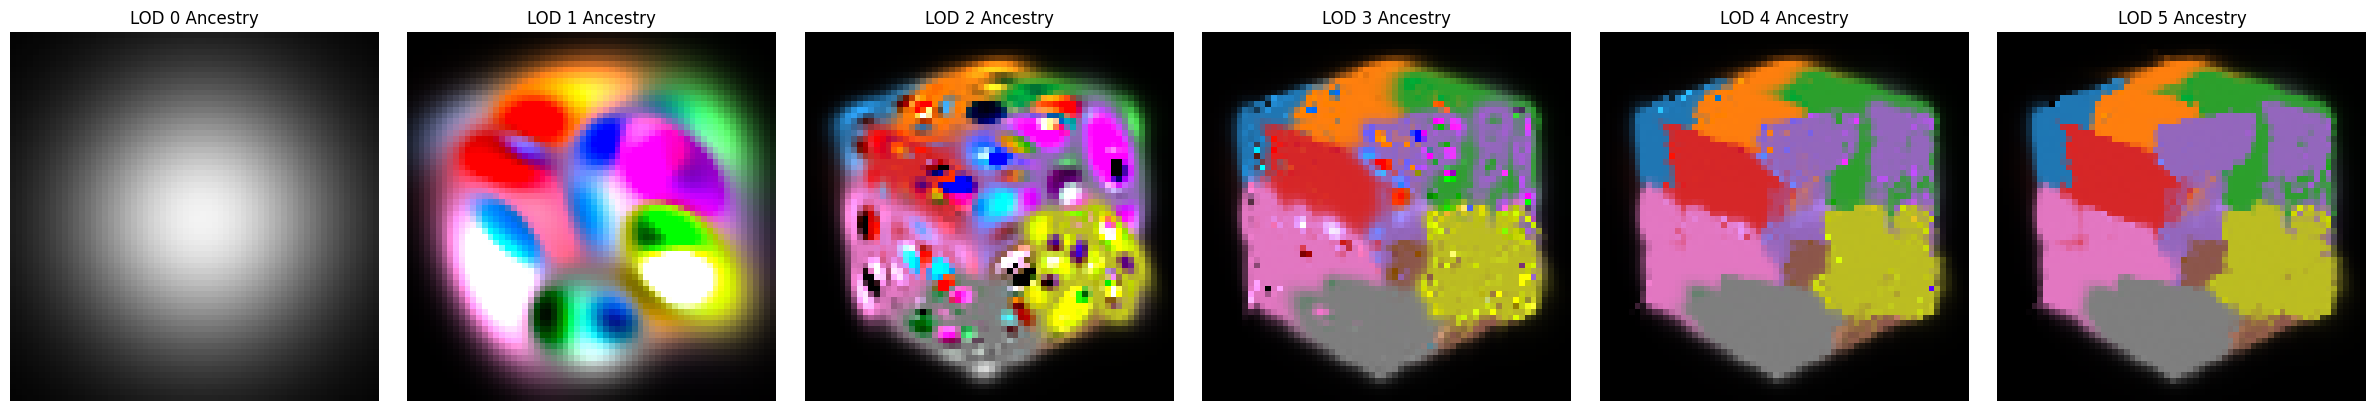

In [ ]:
import matplotlib.cm as cm

@torch.no_grad()
def visualize_ifs_ancestry(model, renderer, max_lod=5):
    print("Generating Ancestry Map for True Recurrent IFS...")
    device = next(model.parameters()).device
    lods = model.get_lod_tensors()

    # Create a distinct 9-color palette
    cmap = plt.get_cmap('tab10')
    branch_colors = torch.tensor([cmap(i)[:3] for i in range(9)], dtype=torch.float32, device=device)

    # Convert target colors to logits (inverse sigmoid)
    clamped_colors = torch.clamp(branch_colors, 1e-4, 1.0 - 1e-4)
    inv_sig_colors = torch.log(clamped_colors / (1.0 - clamped_colors))

    colored_lods = []
    for l, level_data in enumerate(lods):
        new_data = {k: v.clone() for k, v in level_data.items()}

        if l == 0:
            gray_logit = torch.log(torch.tensor([0.5 / (1.0 - 0.5)], device=device))
            new_data['color'] = torch.ones(1, 3, device=device) * gray_logit
        else:
            # Color every descendant based on which of the 9 LOD 1 branches it came from
            nodes_per_branch = 9**(l-1)
            branch_indices = torch.arange(9, device=device).view(9, 1).expand(9, nodes_per_branch).reshape(-1)
            new_data['color'] = inv_sig_colors[branch_indices]

            # Force high opacity so the footprints are fully visible
            new_data['opacity'] = torch.ones_like(new_data['opacity']) * 5.0

        colored_lods.append(new_data)

    # Render and Plot
    fig, axes = plt.subplots(1, max_lod + 1, figsize=(4 * (max_lod + 1), 4))
    for lod in range(max_lod + 1):
        rgb = renderer.render_full_image_chunked(colored_lods, lod, chunk_size=16)
        axes[lod].imshow(rgb.cpu().numpy())
        axes[lod].set_title(f"LOD {lod} Ancestry")
        axes[lod].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization on the IFS model
visualize_ifs_ancestry(model_ifs, renderer_ifs, max_lod=5)

## Parameter Efficiency Comparison: Fourier vs. True IFS

This cell computes the exact number of learnable parameters required to generate a 5-Level (LOD 5) hierarchy using:
1. **Uncompressed Independent Gaussians** (The baseline)
2. **Unshared Fourier Architecture** (5 separate refinement layers)
3. **True Recurrent IFS** (1 shared Gabor refinement layer)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 1. Calculate Uncompressed Baseline
# At LOD 5, we have 9^0 + 9^1 + 9^2 + 9^3 + 9^4 + 9^5 = 66,430 total Gaussians
total_gaussians_lod5 = sum(9**i for i in range(6))
# Each Gaussian has: mu(2) + scale(2) + rot(1) + z(1) + color(3) + opacity(1) = 10 parameters
independent_params = total_gaussians_lod5 * 10

# 2. Setup Unshared Fourier Model (Recreated from earlier for counting)
class DummyFourierModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.root_params = nn.ParameterList([nn.Parameter(torch.zeros(10))])
        # 5 separate layers
        self.refs = nn.ModuleList([ColorTensorRefinement(9**i) for i in range(5)])

fourier_model = DummyFourierModel()
fourier_params = count_parameters(fourier_model)

# 3. Setup True Recurrent IFS Model (Now with only 4 filters!)
ifs_model = TrueIFSColorModel(num_filters=4)
ifs_params = count_parameters(ifs_model)

# Print Results
print("="*50)
print(" PARAMETER EFFICIENCY (LOD 5)")
print("="*50)
print(f"Independent Gaussians: {independent_params:,} parameters")
print(f"Unshared Fourier:      {fourier_params:,} parameters ({independent_params/fourier_params:.1f}x compression)")
print(f"True Recurrent IFS:    {ifs_params:,} parameters ({independent_params/ifs_params:.1f}x compression)")
print("="*50)


 PARAMETER EFFICIENCY (LOD 5)
Independent Gaussians: 664,300 parameters
Unshared Fourier:      4,465 parameters (148.8x compression)
True Recurrent IFS:    1,116 parameters (595.3x compression)


## Hypothesis Test: Pure Affine IFS (Zero Spatial Filters)

Testing the hypothesis that the Gabor filters were redundant and the recurrent Affine transformations (using parent state) are doing all the real work.

This architecture completely removes the $(r, \theta)$ spatial lookup. A parent decides how to spawn its children **exclusively** based on its current `scale`, `rotation`, and `color`.

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image

def load_color_target_full(path):
    img = Image.open(path).convert("RGBA")
    img_t = T.ToTensor()(img)
    return img_t[:3].permute(1, 2, 0), img_t[3] # rgb, alpha

# --- Chunked Memory-Safe Renderer ---
class PatchColorTensorRenderer:
    def __init__(self, image_size, device='cpu'):
        self.image_size = image_size
        self.device = device
        H, W = image_size
        y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
        self.grid_flat = torch.stack([x, y], dim=-1).view(-1, 2)

    def get_frontier_tensors(self, lods, target_lod):
        frontiers = []
        current_prob = torch.ones(1, 1, device=self.device)
        for l in range(target_lod + 1):
            d = lods[l]
            prob_stop = current_prob if l == target_lod else current_prob * (1 - d['split_prob'])
            z_val = d.get('z', torch.zeros_like(d['rot']))
            frontiers.append({'mu': d['mu'], 'scale': d['scale'], 'rot': d['rot'], 'z': z_val, 'color': d['color'], 'opacity': d['opacity'], 'prob': prob_stop})
            if l < target_lod:
                current_prob = (current_prob * d['split_prob']).unsqueeze(1).expand(-1, 9, -1).reshape(-1, 1)

        mu = torch.cat([f['mu'] for f in frontiers], dim=0)
        scale = torch.cat([f['scale'] for f in frontiers], dim=0)
        rot = torch.cat([f['rot'] for f in frontiers], dim=0)
        z = torch.cat([f['z'] for f in frontiers], dim=0)
        color = torch.cat([f['color'] for f in frontiers], dim=0)
        opacity = torch.cat([f['opacity'] for f in frontiers], dim=0)
        prob = torch.cat([f['prob'] for f in frontiers], dim=0)
        return mu, scale, rot, z, color, opacity, prob

    def render_patch(self, lods, target_lod, sampled_coords, gaussian_chunk_size=1024):
        mu, scale, rot, z, color, opacity, prob = self.get_frontier_tensors(lods, target_lod)

        indices = torch.argsort(z.view(-1), descending=True)
        mu, scale, rot, color, opacity, prob = mu[indices], scale[indices], rot[indices], color[indices], opacity[indices], prob[indices]

        N_gaussians = mu.shape[0]
        H_pixels = sampled_coords.shape[0]

        acc_rgb = torch.zeros((H_pixels, 3), device=self.device)
        acc_alpha = torch.zeros((H_pixels, 1), device=self.device)
        visibility = torch.ones((H_pixels, 1), device=self.device)

        for i in range(0, N_gaussians, gaussian_chunk_size):
            end = min(i + gaussian_chunk_size, N_gaussians)
            m_c = mu[i:end]
            s_c = scale[i:end]
            r_c = rot[i:end]
            c_c = torch.sigmoid(color[i:end])
            o_c = opacity[i:end]
            p_c = prob[i:end]

            diff = sampled_coords.unsqueeze(0) - m_c.unsqueeze(1)
            cos_t, sin_t = torch.cos(r_c), torch.sin(r_c)

            rot_x = diff[:, :, 0] * cos_t - diff[:, :, 1] * sin_t
            rot_y = diff[:, :, 0] * sin_t + diff[:, :, 1] * cos_t
            dist_sq = (rot_x / (s_c[:, 0:1] + 1e-8))**2 + (rot_y / (s_c[:, 1:2] + 1e-8))**2

            alpha_chunk = (o_c * p_c) * torch.exp(-0.5 * dist_sq)

            for j in range(alpha_chunk.shape[0]):
                a = alpha_chunk[j:j+1].t()
                color_val = c_c[j:j+1]
                acc_rgb = acc_rgb + visibility * a * color_val
                acc_alpha = acc_alpha + visibility * a
                visibility = visibility * (1.0 - a)

        return torch.clamp(acc_rgb, 0, 1), torch.clamp(acc_alpha.squeeze(), 0, 1)

    def render_full_image_chunked(self, lods, target_lod, chunk_size=32):
        H, W = self.image_size
        full_rgb = torch.zeros((H, W, 3), device=self.device)
        y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=self.device), torch.linspace(-1, 1, W, device=self.device), indexing='ij')

        with torch.no_grad():
            for y_s in range(0, H, chunk_size):
                for x_s in range(0, W, chunk_size):
                    y_e, x_e = min(y_s + chunk_size, H), min(x_s + chunk_size, W)
                    grid_chunk = torch.stack([x[y_s:y_e, x_s:x_e], y[y_s:y_e, x_s:x_e]], dim=-1).view(-1, 2)
                    rgb, _ = self.render_patch(lods, target_lod, grid_chunk)
                    full_rgb[y_s:y_e, x_s:x_e] = rgb.view(y_e-y_s, x_e-x_s, 3)
        return full_rgb

# --- Pure Affine IFS Refinement Module (No Gabor) ---
class PureAffineIFSRefinement(nn.Module):
    def __init__(self, device='cpu'):
        super().__init__()
        self.device = device
        self.num_children = 9

        offset = math.sqrt(2.0 / 3.0)
        base_delta = torch.tensor([
            [-offset, -offset], [ 0.0, -offset], [ offset, -offset],
            [-offset,  0.0],    [ 0.0,  0.0],    [ offset,  0.0],
            [-offset,  offset], [ 0.0,  offset], [ offset,  offset]
        ], device=device)
        self.register_buffer('base_Delta', base_delta)

        # Features: DC(1) + Scale(2) + Rot(1) + Color(3) = 7
        num_features = 7

        self.weight_mu = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.weight_scale = nn.Parameter(torch.zeros(num_features, 9, 2, device=device))
        self.weight_rot = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_z = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_rgb = nn.Parameter(torch.zeros(num_features, 9, 3, device=device))
        self.weight_a = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))
        self.weight_q = nn.Parameter(torch.zeros(num_features, 9, 1, device=device))

        # Initialize DC terms (index 0) for stable base values
        with torch.no_grad():
            self.weight_scale[0, :, :] = math.log(1.0 / 3.0)
            self.weight_a[0, :, 0] = 3.0

    def forward(self, mu, scale, rot, z, color, opacity):
        N = mu.shape[0]

        # State-Aware Concatenation (NO GABOR FILTERS)
        dc_term = torch.ones(N, 1, device=self.device)
        safe_scale = torch.tanh(scale)
        safe_rot = torch.sin(rot)
        safe_color = torch.tanh(color)

        # Only 7 features total!
        F_basis = torch.cat([dc_term, safe_scale, safe_rot, safe_color], dim=1) # (N, 7)

        # Project features into parameter deltas
        res_mu = torch.tanh(torch.einsum('nf, fcd -> ncd', F_basis, self.weight_mu))

        delta_scale = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_scale)
        delta_scale = torch.clamp(delta_scale, min=-6.0, max=1.0)

        delta_rot = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_rot)
        delta_z = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_z)
        delta_rgb = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_rgb)
        a = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_a)
        q = torch.einsum('nf, fcd -> ncd', F_basis, self.weight_q)

        # Apply deltas to parent to spawn children
        avg_scale = scale.mean(dim=-1, keepdim=True)
        mu_child = mu.unsqueeze(1) + avg_scale.unsqueeze(1) * (self.base_Delta + res_mu)
        scale_child = scale.unsqueeze(1) * torch.exp(delta_scale)
        rot_child = rot.unsqueeze(1) + delta_rot
        z_child = z.unsqueeze(1) + delta_z
        color_child = color.unsqueeze(1) + delta_rgb
        opacity_child = opacity.unsqueeze(1) * torch.sigmoid(a)
        split_prob_child = torch.sigmoid(q)

        N_new = N * 9
        return (
            mu_child.reshape(N_new, 2), scale_child.reshape(N_new, 2), rot_child.reshape(N_new, 1),
            z_child.reshape(N_new, 1), color_child.reshape(N_new, 3), opacity_child.reshape(N_new, 1), split_prob_child.reshape(N_new, 1)
        )

# --- Unified Recurrent Model ---
class PureAffineIFSColorModel(nn.Module):
    def __init__(self, device='cpu'):
        super().__init__()
        self.root_mu = nn.Parameter(torch.zeros(1, 2, device=device))
        self.root_scale = nn.Parameter(torch.ones(1, 2, device=device) * 0.5)
        self.root_rot = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_z = nn.Parameter(torch.zeros(1, 1, device=device))
        self.root_color = nn.Parameter(torch.zeros(1, 3, device=device))
        self.root_opacity = nn.Parameter(torch.ones(1, 1, device=device))
        self.root_split = nn.Parameter(torch.zeros(1, 1, device=device))

        self.recurrent_refinement = PureAffineIFSRefinement(device=device)

    def get_lod_tensors(self):
        lods = [{'mu': self.root_mu, 'scale': self.root_scale, 'rot': self.root_rot, 'z': self.root_z, 'color': self.root_color, 'opacity': self.root_opacity, 'split_prob': torch.sigmoid(self.root_split)}]
        for _ in range(5):
            p = lods[-1]
            lods.append(dict(zip(['mu','scale','rot','z','color','opacity','split_prob'],
                                 self.recurrent_refinement(p['mu'], p['scale'], p['rot'], p['z'], p['color'], p['opacity']))))
        return lods

# --- Execution & Training ---
def train_pure_affine_ifs(target_rgb, target_a, iterations=1000, device='cpu'):
    print(f"Training Pure Affine IFS Model (ZERO Gabor Filters) with Z-Depth and LOD 5...")
    H, W = target_rgb.shape[:2]

    model = PureAffineIFSColorModel(device=device).to(device)
    renderer = PatchColorTensorRenderer((H, W), device)
    optimizer = optim.Adam(model.parameters(), lr=0.02)

    y, x = torch.meshgrid(torch.linspace(-1, 1, H, device=device), torch.linspace(-1, 1, W, device=device), indexing='ij')
    coords_flat = torch.stack([x, y], dim=-1).view(-1, 2)
    target_rgb_flat = target_rgb.reshape(-1, 3)
    target_a_flat = target_a.reshape(-1)

    num_samples = 1024

    for i in range(iterations):
        optimizer.zero_grad()
        lods = model.get_lod_tensors()

        indices = torch.randint(0, H*W, (num_samples,), device=device)
        s_coords = coords_flat[indices]
        s_rgb = target_rgb_flat[indices]
        s_a = target_a_flat[indices]

        total_loss = 0
        for lod in range(6):
            rgb, alpha = renderer.render_patch(lods, lod, s_coords)
            loss = F.mse_loss(rgb * s_a.unsqueeze(-1), s_rgb * s_a.unsqueeze(-1)) + F.mse_loss(alpha, s_a)
            total_loss += loss

        total_loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(f"Iter {i+1}, Loss: {total_loss.item():.4f}")
            torch.cuda.empty_cache()

    # Bonus: Print new parameter count!
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n>>> TOTAL LEARNABLE PARAMETERS: {total_params} <<<")

    return model, renderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- Select Target Image ---
target_image_name = 'portrait.png' # @param ["rubik_cube.png", "character.png", "portrait.png", "sphere.png"]
image_path = f'/content/sample_data/{target_image_name}'

print(f"Loading target: {target_image_name}")
t_rgb_full, t_a_full = load_color_target_full(image_path)
t_rgb_64 = F.interpolate(t_rgb_full.permute(2,0,1).unsqueeze(0), size=(64,64), mode='bilinear', align_corners=False).squeeze(0).permute(1,2,0)
t_a_64 = F.interpolate(t_a_full.unsqueeze(0).unsqueeze(0), size=(64,64), mode='bilinear', align_corners=False).squeeze()

model_pure_ifs, renderer_pure_ifs = train_pure_affine_ifs(t_rgb_64.to(device), t_a_64.to(device), iterations=1000, device=device)

fig, axes = plt.subplots(1, 7, figsize=(28, 4))
axes[0].imshow(t_rgb_64.cpu()); axes[0].set_title(f"Target: {target_image_name}")
for lod in range(6):
    rgb = renderer_pure_ifs.render_full_image_chunked(model_pure_ifs.get_lod_tensors(), lod, chunk_size=16)
    axes[lod+1].imshow(rgb.detach().cpu()); axes[lod+1].set_title(f"Pure Affine LOD {lod}")
plt.tight_layout()
plt.show()

Training Pure Affine IFS Model (ZERO Gabor Filters) with Z-Depth and LOD 5...
Iter 100, Loss: 0.4621
Iter 200, Loss: 0.4285
Iter 300, Loss: 0.3752
Iter 400, Loss: 0.3876
Iter 500, Loss: 0.3777
